#  Text Classification and Embeddings

> This works was developed by Jhony and Kevin
---

## Dataset

The first work is load dataset, I take the decision of using IMDB classification dataset. The main reason is easier use this dataset for and introductory students in NLP aspects like me. For example the dataset are clean (without null-values or outliers) and have real data which is a good practice for learning about real world applications.

IMDB classification have two **columns**:
1. text (The user's review)
2. label (Positive review (1) or Negative review (0))

In the following cells you can find some information such as number of samples, number of classes and class distribution.

In [1]:
from datasets import load_dataset
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt 
import nltk
import seaborn as sns

dataset = load_dataset('imdb')

c:\Users\Usuario\Documents\YachayTech\Seventh_semester\NLP\code\Natural-Language-Processing-Course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train = dataset['train'].to_pandas()
df_test = dataset['test'].to_pandas()
df_general = pd.concat([dataset['train'].to_pandas(), dataset['test'].to_pandas()])

**Number of samples**

In [3]:
print("The total number of samples in the general dataset is:", df_general.shape[0])

print()

print("The total number of samples in the training dataset is:", df_train.shape[0])

print()

print("The total number of samples in the test dataset is:", df_test.shape[0])

The total number of samples in the general dataset is: 50000

The total number of samples in the training dataset is: 25000

The total number of samples in the test dataset is: 25000


**Number of classes**

In [4]:
for i, column in enumerate(df_general.columns):
    print(f"Column {i}: '{column}'") 

Column 0: 'text'
Column 1: 'label'


In [5]:
print("Number of classes in label column:", df_general['label'].nunique())
print("Unique classes in label column:", df_general['label'].unique())

Number of classes in label column: 2
Unique classes in label column: [0 1]


**Class distribution**

In [6]:
print(f"Class distribution in the general dataset:\n{df_general['label'].value_counts()}")

Class distribution in the general dataset:
label
0    25000
1    25000
Name: count, dtype: int64


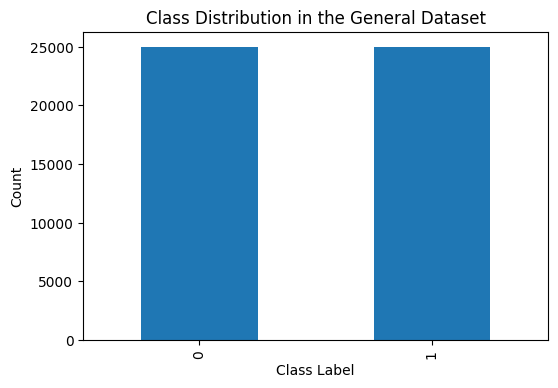

In [7]:
plt.figure(figsize=(6, 4))
df_general['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution in the General Dataset')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

Above we can see that our dataset is'nt unbalaced. We have 25000 for 0 (negative review) and 25000 1 (positive review). This type of distribution data is useful for introductory exercises about natural language processing. 

## Part 1: Baseline Model (Traditional NLP)
---

### Text Preprocessing

**Lowercase**

Lowercasing helps to machines understand the language normalizing the data. Because the text is threated as ASCII or Unicode characters. So have same words written different with uppercase letters affect the statistical correlations between words.

In [8]:
df_train['text_lowercase'] = df_train['text'].str.lower()
df_test['text_lowercase'] = df_test['text'].str.lower()

**Stopword Removal**

This technique is useful because removing grammatical noise such as highly common or structural words of a language. This removal helps models to reduce computational complexity and contain the entire sentence's contextual and emotional payload.

In [9]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stop_words.remove('not')  # Keep 'not' for sentiment context

def remove_stopwords(text):
    # Split text into tokens (words)
    tokens = text.split()
    
    # Remove stopwords
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    
    # Join back into a single string
    return ' '.join(filtered_tokens)

df_train['text_no_stopwords'] = df_train['text_lowercase'].apply(remove_stopwords)
df_test['text_no_stopwords'] = df_test['text_lowercase'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
df_train.head()

,text,label,text_lowercase,text_no_stopwords
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,i rented i am curious-yellow from my video sto...,rented curious-yellow video store controversy ...
1,"""I Am Curious: Yellow"" is a risible and preten...",0,"""i am curious: yellow"" is a risible and preten...","""i curious: yellow"" risible pretentious steami..."
2,If only to avoid making this type of film in t...,0,if only to avoid making this type of film in t...,avoid making type film future. film interestin...
3,This film was probably inspired by Godard's Ma...,0,this film was probably inspired by godard's ma...,"film probably inspired godard's masculin, fémi..."
4,"Oh, brother...after hearing about this ridicul...",0,"oh, brother...after hearing about this ridicul...","oh, brother...after hearing ridiculous film um..."


**Lemmatization**

This technique take all words and verify the similarity for put ocurrences together and reduce the number of differente words and affects the model. For example:
- frustrates, frustrated and frustrating 
Have the same context, however models to treat the data consider the three words as complately different words, with lemmatization the model reach only three times `frustrate`.


In [11]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # Split text into tokens
    tokens = text.split()
    
    # Lemmatize each token
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join back into a single string
    return ' '.join(lemmatized_tokens)

df_train['text_lemmatized'] = df_train['text_no_stopwords'].apply(lemmatize_text)
df_test['text_lemmatized'] = df_test['text_no_stopwords'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
df_train.head()

,text,label,text_lowercase,text_no_stopwords,text_lemmatized
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,i rented i am curious-yellow from my video sto...,rented curious-yellow video store controversy ...,rented curious-yellow video store controversy ...
1,"""I Am Curious: Yellow"" is a risible and preten...",0,"""i am curious: yellow"" is a risible and preten...","""i curious: yellow"" risible pretentious steami...","""i curious: yellow"" risible pretentious steami..."
2,If only to avoid making this type of film in t...,0,if only to avoid making this type of film in t...,avoid making type film future. film interestin...,avoid making type film future. film interestin...
3,This film was probably inspired by Godard's Ma...,0,this film was probably inspired by godard's ma...,"film probably inspired godard's masculin, fémi...","film probably inspired godard's masculin, fémi..."
4,"Oh, brother...after hearing about this ridicul...",0,"oh, brother...after hearing about this ridicul...","oh, brother...after hearing ridiculous film um...","oh, brother...after hearing ridiculous film um..."


**Tokenization**

Tokenization is the technique for machine can understand human language and take more context about the text. This technique breaks words into smaller parts following a specific rule.

I decided to use two type of tokenizers, the first is the traditional tokenizer of `nltk` library called `word_tokenize` which works with `punkt` model. The second is `BPE` model used in GPT-models, only for curiosity and test what effects have in the final results.

`punkt` model use machine learning to figure out where sentences being and end. The main challenge it solves is deciding whether a period `.` is the end of a sentence or part of an abbreviation. When we ysed `nltk.word_tokenize()` there almost always using the **Penn Treebank Word Tokenizer**. It uses a series of regular expressions (hardcoded rules) designed to parse English text grammatically.

*Specific rules for `punkt` model*
- **Punctuation:** It separates standard punctuation from adjacent words. "Hello, world!" becomes ['Hello', ',', 'world', '!'].

- **Contractions:** It splits standard English contractions into their grammatical stems. "Don't" becomes ['Do', "n't"]. "They'll" becomes ['They', "'ll"].

- **Quotes:** It separates opening and closing quotation marks intelligently.

- **Hyphens:** Words with hyphens (like "state-of-the-art") are usually kept together as a single token, unless specific rules dictate otherwise.

`BPE (Byte Pair Encoding)` used in modern large languages models link GPT-3 or GPT-4. This tokenizer don't use human-defined linguistic rules to split text, they use a statistical approach called **Byte-Level Byte Pair Encoding (BBPE)**.

This approach balances character-level tokenization (which requires too many tokens to represent a word) and word-level tokenization (which struggles with millions of rare words, resulting in "Out of Vocabulary" errors).

*Specific rules for `BPE` model*

- **Pre-tokenization (The Regex Split):** Before BPE even starts, GPT uses a regular expression to roughly split the text into words and punctuation.

- **Byte-Level Initialization:** Instead of looking at characters (which vary wildly across languages), GPT looks at raw UTF-8 bytes. The starting vocabulary is exactly 256 tokens (every possible byte).

- **Frequency Counting:** The algorithm looks at the training data and counts the frequency of every adjacent pair of tokens.

- **The Merge Rule:** It takes the most frequently occurring pair of tokens and merges them into a single, new token.

- **Iteration:** It repeats this process exactly $N$ times, where $N$ is the target vocabulary size.


In [13]:
from nltk.tokenize import word_tokenize

def tokenize_text_nltk(text):
    return word_tokenize(text)

df_train['tokenized_text_nltk'] = df_train['text_lemmatized'].apply(tokenize_text_nltk)
df_test['tokenized_text_nltk'] = df_test['text_lemmatized'].apply(tokenize_text_nltk)

In [14]:
from tokenizers import Tokenizer

tokenizer_bpe = Tokenizer.from_pretrained("gpt2")

df_train['tokenized_text_bpe'] = df_train['text_lemmatized'].apply(lambda x: tokenizer_bpe.encode(x).tokens)
df_test['tokenized_text_bpe'] = df_test['text_lemmatized'].apply(lambda x: tokenizer_bpe.encode(x).tokens)

In the section below we can see two columns applying tokenize metho with `nltk` and `BPE`

In [15]:
df_train.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe
10980,I was expecting a movie similar to Deuce Bigal...,0,i was expecting a movie similar to deuce bigal...,"expecting movie similar deuce bigalow, enjoyed...","expecting movie similar deuce bigalow, enjoyed...","[expecting, movie, similar, deuce, bigalow, ,,...","[ex, pecting, Ġmovie, Ġsimilar, Ġde, uce, Ġbig..."
20284,I was surprised at how a movie could be both c...,1,i was surprised at how a movie could be both c...,surprised movie could cheesy excellent time. f...,surprised movie could cheesy excellent time. f...,"[surprised, movie, could, cheesy, excellent, t...","[sur, pr, ised, Ġmovie, Ġcould, Ġcheesy, Ġexce..."
10786,It SURPRISINGLY had a plot! ;) I've seen movie...,0,it surprisingly had a plot! ;) i've seen movie...,surprisingly plot! ;) seen movies less plot (i...,surprisingly plot! ;) seen movie less plot (i ...,"[surprisingly, plot, !, ;, ), seen, movie, les...","[surprisingly, Ġplot, !, Ġ;), Ġseen, Ġmovie, Ġ..."
9419,The Radar Men from the Moon is a pretty typica...,0,the radar men from the moon is a pretty typica...,radar men moon pretty typical fare 1950's seri...,radar men moon pretty typical fare 1950's seri...,"[radar, men, moon, pretty, typical, fare, 1950...","[rad, ar, Ġmen, Ġmoon, Ġpretty, Ġtypical, Ġfar..."
19391,Don't let my constructive criticism stop you f...,1,don't let my constructive criticism stop you f...,let constructive criticism stop buying watchin...,let constructive criticism stop buying watchin...,"[let, constructive, criticism, stop, buying, w...","[let, Ġconstructive, Ġcriticism, Ġstop, Ġbuyin..."
20341,The film is exceptional in it's gay iconograph...,1,the film is exceptional in it's gay iconograph...,film exceptional gay iconography extends beyon...,film exceptional gay iconography extends beyon...,"[film, exceptional, gay, iconography, extends,...","[film, Ġexceptional, Ġgay, Ġicon, ography, Ġex..."
20800,"Having never seen the original Dirty Harry, I ...",1,"having never seen the original dirty harry, i ...","never seen original dirty harry, judged movie ...","never seen original dirty harry, judged movie ...","[never, seen, original, dirty, harry, ,, judge...","[never, Ġseen, Ġoriginal, Ġdirty, Ġhar, ry, ,,..."


### Feature Extraction

**Using Bag-of-Words (CountVectorizer)**

Here for the using of BoW I want to prove three combinations.
- Few features (e.g. 1000 words as max_features for making the matrix)
- Medium/High features (e.g. 5000 words as max_features for making the matrix)
- None features (All words as max_features for making the matrix)

`CountVectorizer` with `max_features=1000`

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

cv_1000 = CountVectorizer(max_features=1000)

X_train_bow_1000 = cv_1000.fit_transform(df_train['text_lemmatized'])
X_test_bow_1000 = cv_1000.transform(df_test['text_lemmatized'])

In [17]:
print(f"Vocabulary size (max_features=1000): {len(cv_1000.vocabulary_)}")

Vocabulary size (max_features=1000): 1000


`CountVectorizer` with `max_features=5000`

In [18]:
cv_5000 = CountVectorizer(max_features=5000)
X_train_bow_5000 = cv_5000.fit_transform(df_train['text_lemmatized'])
X_test_bow_5000 = cv_5000.transform(df_test['text_lemmatized'])

In [19]:
print(f"Vocabulary size (max_features=5000): {len(cv_5000.vocabulary_)}")

Vocabulary size (max_features=5000): 5000


`CountVectorizer` without `max_features`

In [20]:
cv_max = CountVectorizer()
X_train_bow_max = cv_max.fit_transform(df_train['text_lemmatized'])
X_test_bow_max = cv_max.transform(df_test['text_lemmatized'])

In [21]:
print(f"Vocabulary size (no limit): {len(cv_max.vocabulary_)}")

Vocabulary size (no limit): 72713


Visualize the different matrix of BoW for (1000, 5000 and max number of words.)

| It's only for training data

*Disclaimer*
> The code below was generated with the assistant of `Claude Haiku 4.5` for giving more informative visualization about the use of different values in `max_features` paremeters on `CountVectorizer` class.


RANDOM SUBSET INFORMATION
Random row start index: 9194
Random column start index: 96
Review indices: 9194 to 9209
Word indices: 96 to 116



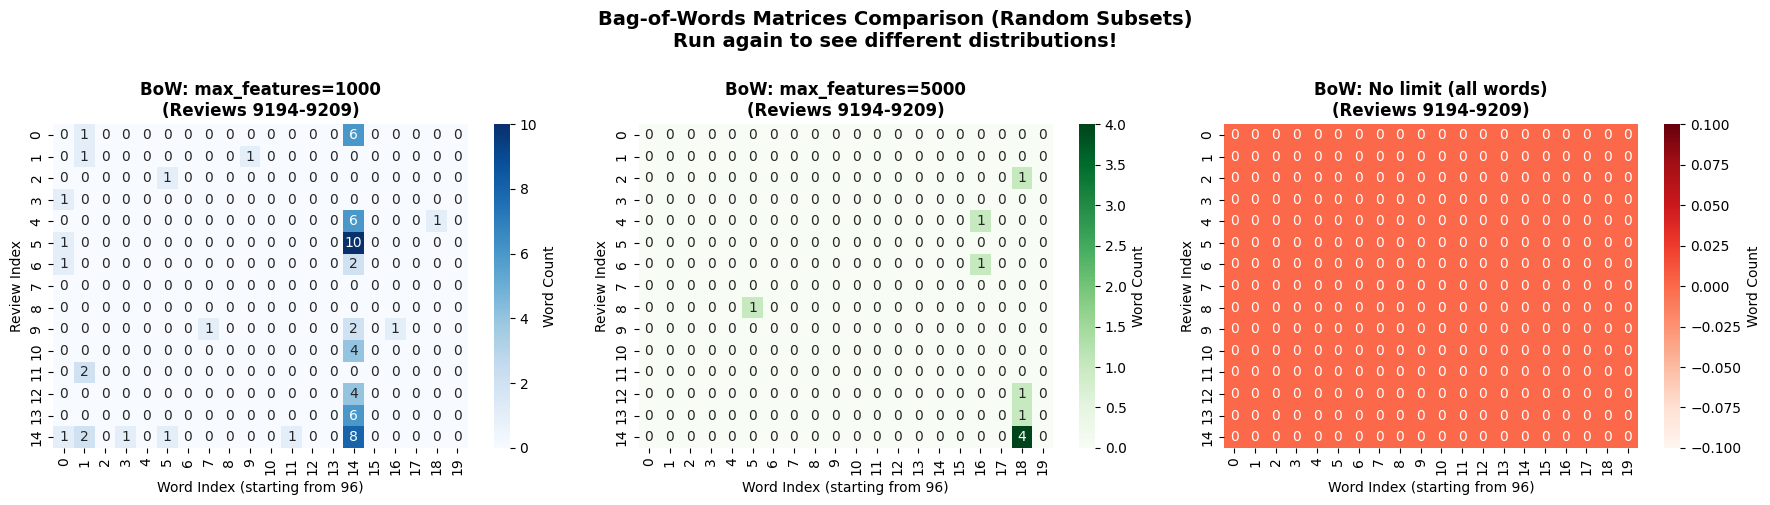

STATISTICS OF RANDOM SUBSETS DISPLAYED
Feature Configuration  Total Values  Non-Zero Values  Max Value  Mean Value
    max_features=1000           300               25         10    0.220000
    max_features=5000           300                7          4    0.033333
             No limit           300                0          0    0.000000

💡 TIP: Run this cell multiple times to see different distributions!
    Each run selects a random subset from the matrices.



In [22]:
# ============================================================================
# VISUALIZATION: Three BoW matrices with RANDOM subsets (subplots)
# ============================================================================

# Set random seed for reproducibility (comment out for different runs each time)
# np.random.seed(42)

# Define subset dimensions
num_reviews_display = 15  # Number of reviews to display
num_words_display = 20    # Number of words to display
row_step = 5              # Step size for row variation
col_step = 5              # Step size for column variation

# Generate random starting indices within valid bounds
# For rows: ensure we don't go beyond the training data
max_row_start = X_train_bow_1000.shape[0] - num_reviews_display
random_row_start = np.random.randint(0, max(1, max_row_start), 1)[0]

# For columns: ensure we don't go beyond the vocabulary
# We'll use the smallest vocabulary (1000) to ensure all three subsets are valid
max_col_start = 1000 - num_words_display
random_col_start = np.random.randint(0, max(1, max_col_start), 1)[0]

# Print the random indices for reference
print("\n" + "="*70)
print("RANDOM SUBSET INFORMATION")
print("="*70)
print(f"Random row start index: {random_row_start}")
print(f"Random column start index: {random_col_start}")
print(f"Review indices: {random_row_start} to {random_row_start + num_reviews_display}")
print(f"Word indices: {random_col_start} to {random_col_start + num_words_display}")
print("="*70 + "\n")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================================
# SUBPLOT 1: BoW matrix with max_features=1000 (RANDOM SUBSET)
# ============================================================================

# Extract random subset from sparse matrix and convert to dense
X_subset_1000 = X_train_bow_1000[random_row_start:random_row_start+num_reviews_display, 
                                  random_col_start:random_col_start+num_words_display].toarray()

# Create heatmap for 1000 features
sns.heatmap(X_subset_1000, 
            cmap='Blues',  # Color palette (blue shades)
            cbar_kws={'label': 'Word Count'},
            ax=axes[0],
            annot=True,  # Show actual values in cells
            fmt='.0f',   # Format as integers
            cbar=True)

# Set title with random indices
axes[0].set_title(f'BoW: max_features=1000\n(Reviews {random_row_start}-{random_row_start+num_reviews_display})', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Word Index (starting from {random_col_start})', fontsize=10)
axes[0].set_ylabel('Review Index', fontsize=10)

# ============================================================================
# SUBPLOT 2: BoW matrix with max_features=5000 (RANDOM SUBSET)
# ============================================================================

# Extract random subset from sparse matrix and convert to dense
X_subset_5000 = X_train_bow_5000[random_row_start:random_row_start+num_reviews_display, 
                                  random_col_start:random_col_start+num_words_display].toarray()

# Create heatmap for 5000 features
sns.heatmap(X_subset_5000, 
            cmap='Greens',  # Color palette (green shades)
            cbar_kws={'label': 'Word Count'},
            ax=axes[1],
            annot=True,
            fmt='.0f',
            cbar=True)

# Set title with random indices
axes[1].set_title(f'BoW: max_features=5000\n(Reviews {random_row_start}-{random_row_start+num_reviews_display})', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'Word Index (starting from {random_col_start})', fontsize=10)
axes[1].set_ylabel('Review Index', fontsize=10)

# ============================================================================
# SUBPLOT 3: BoW matrix with no limit (all words) (RANDOM SUBSET)
# ============================================================================

# Extract random subset from sparse matrix and convert to dense
X_subset_max = X_train_bow_max[random_row_start:random_row_start+num_reviews_display, 
                                random_col_start:random_col_start+num_words_display].toarray()

# Create heatmap for all features
sns.heatmap(X_subset_max, 
            cmap='Reds',  # Color palette (red shades)
            cbar_kws={'label': 'Word Count'},
            ax=axes[2],
            annot=True,
            fmt='.0f',
            cbar=True)

# Set title with random indices
axes[2].set_title(f'BoW: No limit (all words)\n(Reviews {random_row_start}-{random_row_start+num_reviews_display})', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'Word Index (starting from {random_col_start})', fontsize=10)
axes[2].set_ylabel('Review Index', fontsize=10)

# Adjust overall layout
fig.suptitle('Bag-of-Words Matrices Comparison (Random Subsets)\nRun again to see different distributions!',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICS OF THE RANDOM SUBSETS
# ============================================================================

print("="*90)
print("STATISTICS OF RANDOM SUBSETS DISPLAYED")
print("="*90)

subset_stats = {
    'Feature Configuration': ['max_features=1000', 'max_features=5000', 'No limit'],
    'Total Values': [X_subset_1000.size, X_subset_5000.size, X_subset_max.size],
    'Non-Zero Values': [np.count_nonzero(X_subset_1000), 
                        np.count_nonzero(X_subset_5000), 
                        np.count_nonzero(X_subset_max)],
    'Max Value': [np.max(X_subset_1000), np.max(X_subset_5000), np.max(X_subset_max)],
    'Mean Value': [np.mean(X_subset_1000), np.mean(X_subset_5000), np.mean(X_subset_max)]
}

stats_df = pd.DataFrame(subset_stats)
print(stats_df.to_string(index=False))
print("="*90 + "\n")

print("💡 TIP: Run this cell multiple times to see different distributions!")
print("    Each run selects a random subset from the matrices.\n")

In the above `cell output` we can see the different distribution about the frequency of the words in reviews. In the majority of the runnings, the less values of `max_features` (1000 and 5000) have higher values respect to use the maximun number features (`max_features`). And is useful because, with more frequency on documents of the corpus, models can understand the importance or contextual weight for classificate the sentimental output.

In [23]:
def show_top_10_words(Count_Vectorizer):
    i = 0
    print(f"Top 10 words in the vocabulary of CountVectorizer (max_features={len(Count_Vectorizer.vocabulary_)})")
    for word, index in Count_Vectorizer.vocabulary_.items():
        if i < 10:
            print(f"{i+1}. '{word}' (index: {index})")
            i += 1
        else:
            break

In [24]:
show_top_10_words(cv_1000)

Top 10 words in the vocabulary of CountVectorizer (max_features=1000)
1. 'video' (index: 928)
2. 'store' (index: 820)
3. 'first' (index: 334)
4. 'released' (index: 707)
5. 'also' (index: 35)
6. 'heard' (index: 401)
7. 'ever' (index: 284)
8. 'tried' (index: 895)
9. 'country' (index: 185)
10. 'fan' (index: 307)


In [25]:
show_top_10_words(cv_5000)

Top 10 words in the vocabulary of CountVectorizer (max_features=5000)
1. 'rented' (index: 3647)
2. 'curious' (index: 1099)
3. 'yellow' (index: 4983)
4. 'video' (index: 4754)
5. 'store' (index: 4232)
6. 'surrounded' (index: 4348)
7. 'first' (index: 1744)
8. 'released' (index: 3620)
9. 'also' (index: 218)
10. 'heard' (index: 2083)


In [26]:
show_top_10_words(cv_max)

Top 10 words in the vocabulary of CountVectorizer (max_features=72713)
1. 'rented' (index: 53375)
2. 'curious' (index: 15600)
3. 'yellow' (index: 72063)
4. 'video' (index: 69238)
5. 'store' (index: 61596)
6. 'controversy' (index: 14214)
7. 'surrounded' (index: 62830)
8. 'first' (index: 24079)
9. 'released' (index: 53143)
10. '1967' (index: 369)


**Use TF-IDF**

Here also I test with three different values for `max_features` parameter.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF with max_features=1000
tfidf_1000 = TfidfVectorizer(max_features=1000)
X_train_tfidf_1000 = tfidf_1000.fit_transform(df_train['text_lemmatized'])
X_test_tfidf_1000 = tfidf_1000.transform(df_test['text_lemmatized'])

# TF-IDF with max_features=5000
tfidf_5000 = TfidfVectorizer(max_features=5000)
X_train_tfidf_5000 = tfidf_5000.fit_transform(df_train['text_lemmatized'])
X_test_tfidf_5000 = tfidf_5000.transform(df_test['text_lemmatized'])

# TF-IDF with no limit
tfidf_max = TfidfVectorizer()
X_train_tfidf_max = tfidf_max.fit_transform(df_train['text_lemmatized'])
X_test_tfidf_max = tfidf_max.transform(df_test['text_lemmatized'])

In [28]:
# Check vocabulary sizes
print(f"Vocabulary size (max_features=1000): {len(tfidf_1000.vocabulary_)}")
print(f"Vocabulary size (max_features=5000): {len(tfidf_5000.vocabulary_)}")
print(f"Vocabulary size (no limit): {len(tfidf_max.vocabulary_)}")

Vocabulary size (max_features=1000): 1000
Vocabulary size (max_features=5000): 5000
Vocabulary size (no limit): 72713


In [29]:
tfidf_1000.get_feature_names_out().shape

(1000,)

Visualize the different matrix of TF-IDF for (1000, 5000 and max number of words.)

| It's only for training data

Notice that TF-IDF values are **normalized floats** (typically 0-1), unlike BoW counts which are integers. Smaller vocabularies will show **lower values** because words are more concentrated, affecting the weighting distribution.


*Disclaimer*
> The code below was generated with the assistant of `Claude Haiku 4.5` for giving more informative visualization about the use of different values in `max_features` paremeters on `TfidfVectorizer` class.


RANDOM SUBSET INFORMATION
Random row start index: 14031
Random column start index: 619
Review indices: 14031 to 14046
Word indices: 619 to 639



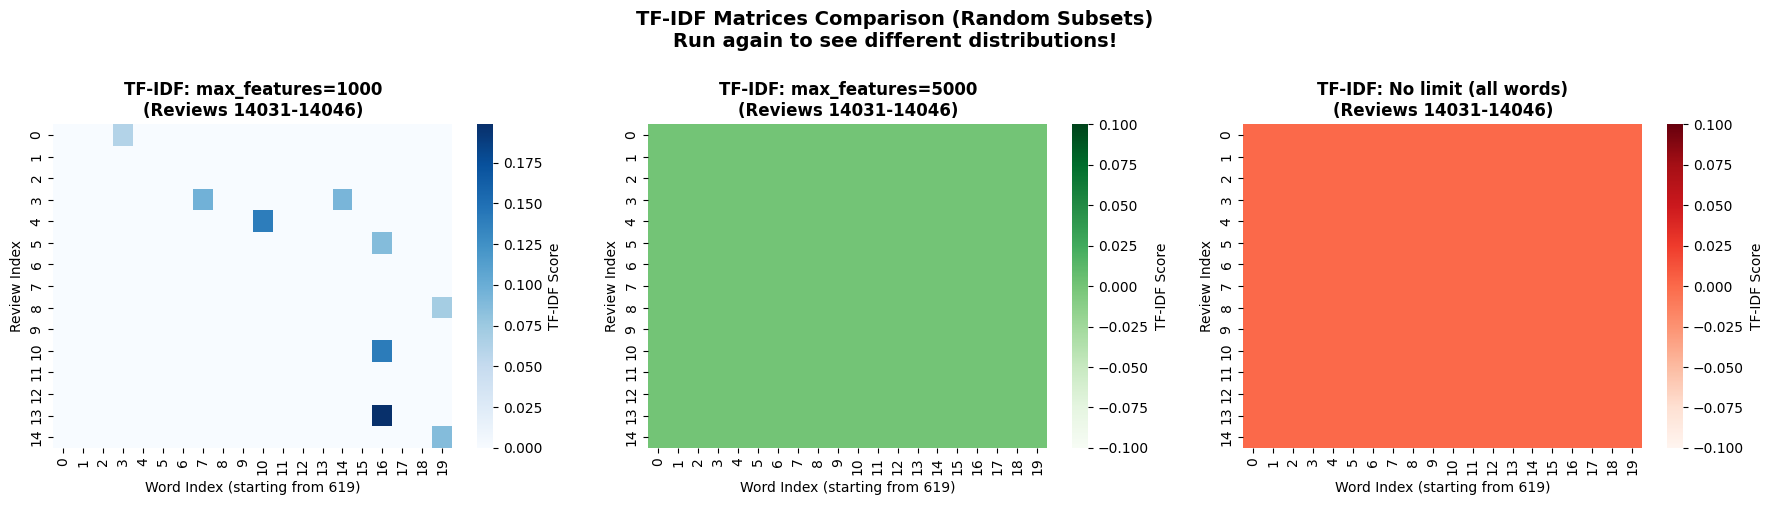

STATISTICS OF RANDOM SUBSETS DISPLAYED (TF-IDF SCORES)
Feature Configuration  Total Values  Non-Zero Values  Max Value  Mean Value
    max_features=1000           300                9   0.198678     0.00325
    max_features=5000           300                0   0.000000     0.00000
             No limit           300                0   0.000000     0.00000

💡 TIP: Run this cell multiple times to see different distributions!
    Each run selects a random subset from the matrices.



In [30]:
# ============================================================================
# VISUALIZATION: Three TF-IDF matrices with RANDOM subsets (subplots)
# ============================================================================

# Set random seed for reproducibility (comment out for different runs each time)
# np.random.seed(42)

# Define subset dimensions
num_reviews_display = 15  # Number of reviews to display
num_words_display = 20    # Number of words to display

# Generate random starting indices within valid bounds
# For rows: ensure we don't go beyond the training data
max_row_start = X_train_tfidf_1000.shape[0] - num_reviews_display
random_row_start = np.random.randint(0, max(1, max_row_start), 1)[0]

# For columns: ensure we don't go beyond the vocabulary
# We'll use the smallest vocabulary (1000) to ensure all three subsets are valid
max_col_start = 1000 - num_words_display
random_col_start = np.random.randint(0, max(1, max_col_start), 1)[0]

# Print the random indices for reference
print("\n" + "="*70)
print("RANDOM SUBSET INFORMATION")
print("="*70)
print(f"Random row start index: {random_row_start}")
print(f"Random column start index: {random_col_start}")
print(f"Review indices: {random_row_start} to {random_row_start + num_reviews_display}")
print(f"Word indices: {random_col_start} to {random_col_start + num_words_display}")
print("="*70 + "\n")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================================
# SUBPLOT 1: TF-IDF matrix with max_features=1000 (RANDOM SUBSET)
# ============================================================================

# Extract random subset from sparse matrix and convert to dense
X_subset_tfidf_1000 = X_train_tfidf_1000[random_row_start:random_row_start+num_reviews_display, 
                                          random_col_start:random_col_start+num_words_display].toarray()

# Create heatmap for 1000 features
sns.heatmap(X_subset_tfidf_1000, 
            cmap='Blues',  # Color palette (blue shades)
            cbar_kws={'label': 'TF-IDF Score'},
            ax=axes[0],
            fmt='.2f',   # Format as 2 decimal places (floats)
            cbar=True)

# Set title with random indices
axes[0].set_title(f'TF-IDF: max_features=1000\n(Reviews {random_row_start}-{random_row_start+num_reviews_display})', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Word Index (starting from {random_col_start})', fontsize=10)
axes[0].set_ylabel('Review Index', fontsize=10)

# ============================================================================
# SUBPLOT 2: TF-IDF matrix with max_features=5000 (RANDOM SUBSET)
# ============================================================================

# Extract random subset from sparse matrix and convert to dense
X_subset_tfidf_5000 = X_train_tfidf_5000[random_row_start:random_row_start+num_reviews_display, 
                                          random_col_start:random_col_start+num_words_display].toarray()

# Create heatmap for 5000 features
sns.heatmap(X_subset_tfidf_5000, 
            cmap='Greens',  # Color palette (green shades)
            cbar_kws={'label': 'TF-IDF Score'},
            ax=axes[1],
            fmt='.2f',
            cbar=True)

# Set title with random indices
axes[1].set_title(f'TF-IDF: max_features=5000\n(Reviews {random_row_start}-{random_row_start+num_reviews_display})', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'Word Index (starting from {random_col_start})', fontsize=10)
axes[1].set_ylabel('Review Index', fontsize=10)

# ============================================================================
# SUBPLOT 3: TF-IDF matrix with no limit (all words) (RANDOM SUBSET)
# ============================================================================

# Extract random subset from sparse matrix and convert to dense
X_subset_tfidf_max = X_train_tfidf_max[random_row_start:random_row_start+num_reviews_display, 
                                        random_col_start:random_col_start+num_words_display].toarray()

# Create heatmap for all features
sns.heatmap(X_subset_tfidf_max, 
            cmap='Reds',  # Color palette (red shades)
            cbar_kws={'label': 'TF-IDF Score'},
            ax=axes[2],
            fmt='.2f',
            cbar=True)

# Set title with random indices
axes[2].set_title(f'TF-IDF: No limit (all words)\n(Reviews {random_row_start}-{random_row_start+num_reviews_display})', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'Word Index (starting from {random_col_start})', fontsize=10)
axes[2].set_ylabel('Review Index', fontsize=10)

# Adjust overall layout
fig.suptitle('TF-IDF Matrices Comparison (Random Subsets)\nRun again to see different distributions!',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICS OF THE RANDOM SUBSETS
# ============================================================================

print("="*90)
print("STATISTICS OF RANDOM SUBSETS DISPLAYED (TF-IDF SCORES)")
print("="*90)

subset_stats_tfidf = {
    'Feature Configuration': ['max_features=1000', 'max_features=5000', 'No limit'],
    'Total Values': [X_subset_tfidf_1000.size, X_subset_tfidf_5000.size, X_subset_tfidf_max.size],
    'Non-Zero Values': [np.count_nonzero(X_subset_tfidf_1000), 
                        np.count_nonzero(X_subset_tfidf_5000), 
                        np.count_nonzero(X_subset_tfidf_max)],
    'Max Value': [np.max(X_subset_tfidf_1000), np.max(X_subset_tfidf_5000), np.max(X_subset_tfidf_max)],
    'Mean Value': [np.mean(X_subset_tfidf_1000), np.mean(X_subset_tfidf_5000), np.mean(X_subset_tfidf_max)]
}

stats_tfidf_df = pd.DataFrame(subset_stats_tfidf)
print(stats_tfidf_df.to_string(index=False))
print("="*90 + "\n")

print("💡 TIP: Run this cell multiple times to see different distributions!")
print("    Each run selects a random subset from the matrices.\n")


Similarity with the different testing on BoW about the `max_features` parameter. Here have the similar behavior, with less `max_features` we can see more information about low and high TF-IDF values for analyzing data and pass information to classifiers.

In [31]:
def show_top_10_words(TF_IDF_Vectorizer):
    i = 0
    print(f"Top 10 words in the vocabulary of TF-IDF Vectorizer (max_features={len(TF_IDF_Vectorizer.vocabulary_)})")
    for word, index in TF_IDF_Vectorizer.vocabulary_.items():
        if i < 10:
            print(f"{i+1}. '{word}' (index: {index})")
            i += 1
        else:
            break

In [32]:
show_top_10_words(tfidf_1000)

Top 10 words in the vocabulary of TF-IDF Vectorizer (max_features=1000)
1. 'video' (index: 928)
2. 'store' (index: 820)
3. 'first' (index: 334)
4. 'released' (index: 707)
5. 'also' (index: 35)
6. 'heard' (index: 401)
7. 'ever' (index: 284)
8. 'tried' (index: 895)
9. 'country' (index: 185)
10. 'fan' (index: 307)


In [33]:
show_top_10_words(tfidf_5000)

Top 10 words in the vocabulary of TF-IDF Vectorizer (max_features=5000)
1. 'rented' (index: 3647)
2. 'curious' (index: 1099)
3. 'yellow' (index: 4983)
4. 'video' (index: 4754)
5. 'store' (index: 4232)
6. 'surrounded' (index: 4348)
7. 'first' (index: 1744)
8. 'released' (index: 3620)
9. 'also' (index: 218)
10. 'heard' (index: 2083)


In [34]:
show_top_10_words(tfidf_max)

Top 10 words in the vocabulary of TF-IDF Vectorizer (max_features=72713)
1. 'rented' (index: 53375)
2. 'curious' (index: 15600)
3. 'yellow' (index: 72063)
4. 'video' (index: 69238)
5. 'store' (index: 61596)
6. 'controversy' (index: 14214)
7. 'surrounded' (index: 62830)
8. 'first' (index: 24079)
9. 'released' (index: 53143)
10. '1967' (index: 369)


**Comparison: BoW vs TF-IDF**

Key observations:

1. **Value Range**: BoW shows integers (word counts), TF-IDF shows floats (0-1 normalized scores)
2. **Max Values**: TF-IDF max values are typically **lower** than BoW because scores are normalized per document
3. **Sparsity**: TF-IDF might show more zeros (especially in larger vocabularies) because rare, common words get penalized by the IDF component
4. **Distribution**: Smaller vocabularies (1000, 5000) show **higher concentrations** in both BoW and TF-IDF because words are selected by frequency
5. **Discriminative Power**: TF-IDF's normalization means the classifier learns which **important word combinations** distinguish between classes, not just raw frequencies


### Model Training

For the task of classifying the review into their correspond tag I decided to use the following machine learning models:
1. Naive Bayes
2. Logistic Regression

Before to discuss the result of the models. Let's do a little refresh about each type of metrics used for analyze the result of machine and depp learning models.

1. **Accuracy**

    $Accuracy$ = $\frac{TP+TN}{TP+TN+FP+FN}$ $=$ $\frac{Correct\ Predictions}{Total\ Predictions}$

    $Where:$
    - $TP:\ True\ Positive$
    - $TN:\ True\ Negative$
    - $FP:\ False\ Positive$
    - $FN:\ False\ Negative$

    *Definition:* The accuracy counts all **correct predictions** (both positive and negative) and divide by the total of number of predictions. Refers to: *How often is the model correct?*

2. **Precision**

    $Precision$ = $\frac{TP}{TP+FP}$ $=$ $\frac{Correct\ Positive\ Predictions}{All\ Positive\ Predictions}$
    
    *Definition:* The precision counts all **positive prections** which are actually correct. Refers to: *When it predicts positive, how often is it right?*


3. **Recall**

    $Recall$ = $\frac{TP}{TP+FN}$ $=$ $\frac{Correctly\ Predicted\ Positives}{All\ Actuall\ Positives}$

    *Definition:* The recall counts all **successfully prediction no matter the class**. Refers to: *Of all the actual positive reviews, how many did the model successfully identify?*

4. **F1-Score**

    $F1$ = $2 \times \frac{Precision \times Recall}{Precision + Recall}$

    Or equivalently:

    $F1$ = $2 \times \frac{2 \times TP}{2 \times TP+FP+FN}$

    *Definition:* F1-Score is a single metric that balances Precision and Recall using their harmonic mean. Refers to: *It finds a balance between the two.*

#### **Naive Bayes model**

First we test the model with the text representation in Bow, in the differente `max_features` pararameters.

In [35]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


NAIVE BAYES - BoW (1000)

Accuracy: 0.8304

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.83      0.83      0.83     12500
Positive (1)       0.83      0.83      0.83     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000


NAIVE BAYES - BoW (5000)

Accuracy: 0.8360

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.86      0.84     12500
Positive (1)       0.86      0.81      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000


NAIVE BAYES - BoW (max)

Accuracy: 0.8210

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.79      0.88      0.83     12500
Positive (1)       0.86      0.76 

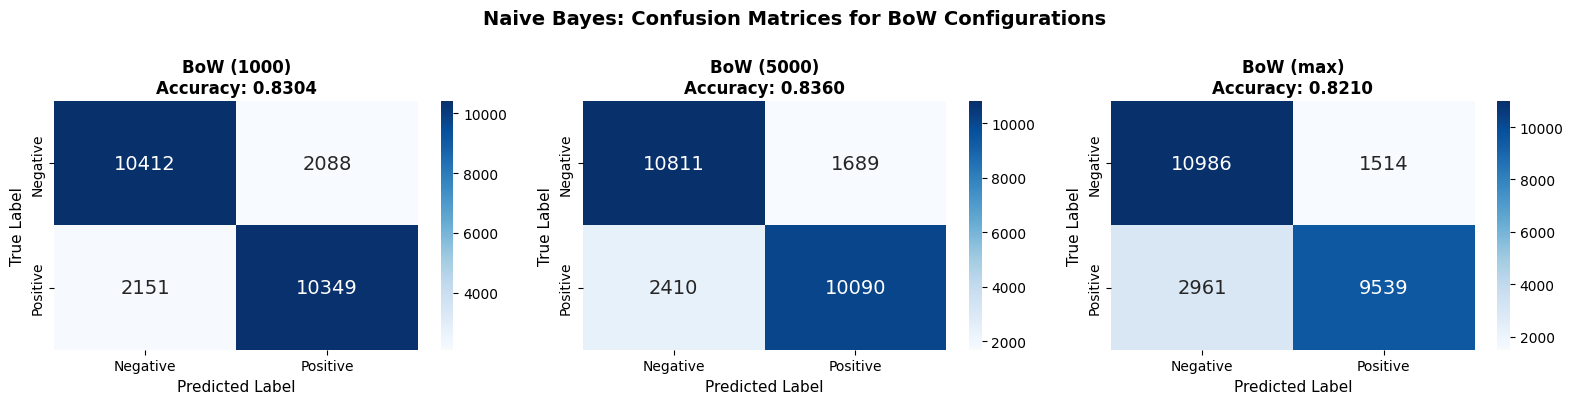


COMPARISON SUMMARY: NAIVE BAYES ON BOW CONFIGURATIONS

Configuration Accuracy Precision Recall F1-Score    TP    TN   FP   FN
   BoW (1000)   0.8304    0.8321 0.8279   0.8300 10349 10412 2088 2151
   BoW (5000)   0.8360    0.8566 0.8072   0.8312 10090 10811 1689 2410
    BoW (max)   0.8210    0.8630 0.7631   0.8100  9539 10986 1514 2961



In [36]:
def evaluate_naive_bayes_bow_configurations(
    X_train_1000, X_test_1000, 
    X_train_5000, X_test_5000, 
    X_train_max, X_test_max, 
    y_train, y_test
):
    """
    Train and evaluate Naive Bayes on three BoW configurations.
    
    Parameters:
    - X_train_1000, X_test_1000: BoW features with 1000 max_features
    - X_train_5000, X_test_5000: BoW features with 5000 max_features
    - X_train_max, X_test_max: BoW features with no limit
    - y_train, y_test: Labels
    
    Returns:
    - Dictionary with models, predictions, and metrics
    """
    
    results = {}
    configurations = [
        ('BoW (1000)', X_train_1000, X_test_1000),
        ('BoW (5000)', X_train_5000, X_test_5000),
        ('BoW (max)', X_train_max, X_test_max)
    ]
    
    # Train and evaluate for each configuration
    for config_name, X_train, X_test in configurations:
        print("\n" + "="*80)
        print(f"NAIVE BAYES - {config_name}")
        print("="*80)
        
        # Create and train model
        model = MultinomialNB()
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        # Store results
        results[config_name] = {
            'model': model,
            'y_pred': y_pred,
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'X_test': X_test
        }
        
        # Print accuracy
        print(f"\nAccuracy: {accuracy:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=['Negative (0)', 'Positive (1)']))
    
    # ========================================================================
    # VISUALIZATION: Confusion Matrices
    # ========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    for idx, (config_name, _, _) in enumerate(configurations):
        conf_matrix = results[config_name]['confusion_matrix']
        
        sns.heatmap(conf_matrix, 
                    annot=True, 
                    fmt='d', 
                    cmap='Blues',
                    cbar=True,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'],
                    ax=axes[idx],
                    annot_kws={'fontsize': 14})
        
        accuracy = results[config_name]['accuracy']
        axes[idx].set_title(f'{config_name}\nAccuracy: {accuracy:.4f}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=11)
        axes[idx].set_xlabel('Predicted Label', fontsize=11)
    
    plt.suptitle('Naive Bayes: Confusion Matrices for BoW Configurations', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # COMPARISON TABLE
    # ========================================================================
    print("\n" + "="*80)
    print("COMPARISON SUMMARY: NAIVE BAYES ON BOW CONFIGURATIONS")
    print("="*80 + "\n")
    
    comparison_data = []
    for config_name, _, _ in configurations:
        conf_matrix = results[config_name]['confusion_matrix']
        accuracy = results[config_name]['accuracy']
        
        # Calculate additional metrics
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        comparison_data.append({
            'Configuration': config_name,
            'Accuracy': f'{accuracy:.4f}',
            'Precision': f'{precision:.4f}',
            'Recall': f'{recall:.4f}',
            'F1-Score': f'{f1:.4f}',
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    
    return results

# Execute the function
results_nb_bow = evaluate_naive_bayes_bow_configurations(
    X_train_bow_1000, X_test_bow_1000,
    X_train_bow_5000, X_test_bow_5000,
    X_train_bow_max, X_test_bow_max,
    df_train['label'], df_test['label']
)


NAIVE BAYES - TF-IDF (1000)

Accuracy: 0.8368

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.84      0.83      0.84     12500
Positive (1)       0.83      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000


NAIVE BAYES - TF-IDF (5000)

Accuracy: 0.8404

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.83      0.86      0.84     12500
Positive (1)       0.85      0.82      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000


NAIVE BAYES - TF-IDF (max)

Accuracy: 0.8315

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.80      0.88      0.84     12500
Positive (1)       0.87  

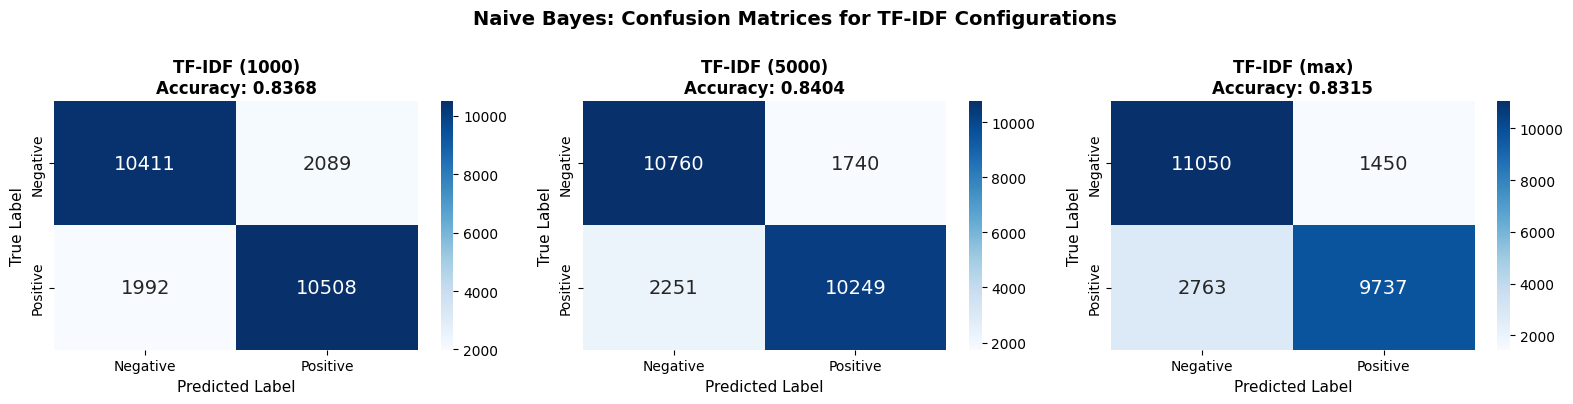


COMPARISON SUMMARY: NAIVE BAYES ON TF-IDF CONFIGURATIONS

Configuration Accuracy Precision Recall F1-Score    TP    TN   FP   FN
TF-IDF (1000)   0.8368    0.8342 0.8406   0.8374 10508 10411 2089 1992
TF-IDF (5000)   0.8404    0.8549 0.8199   0.8370 10249 10760 1740 2251
 TF-IDF (max)   0.8315    0.8704 0.7790   0.8221  9737 11050 1450 2763



In [37]:
def evaluate_naive_bayes_tfidf_configurations(
    X_train_1000, X_test_1000, 
    X_train_5000, X_test_5000, 
    X_train_max, X_test_max, 
    y_train, y_test
):
    """
    Train and evaluate Naive Bayes on three TF-IDF configurations.
    
    Parameters:
    - X_train_1000, X_test_1000: TF-IDF features with 1000 max_features
    - X_train_5000, X_test_5000: TF-IDF features with 5000 max_features
    - X_train_max, X_test_max: TF-IDF features with no limit
    - y_train, y_test: Labels
    
    Returns:
    - Dictionary with models, predictions, and metrics
    """

    
    results = {}
    configurations = [
        ('TF-IDF (1000)', X_train_1000, X_test_1000),
        ('TF-IDF (5000)', X_train_5000, X_test_5000),
        ('TF-IDF (max)', X_train_max, X_test_max)
    ]
    
    # Train and evaluate for each configuration
    for config_name, X_train, X_test in configurations:
        print("\n" + "="*80)
        print(f"NAIVE BAYES - {config_name}")
        print("="*80)
        
        # Create and train model
        model = MultinomialNB()
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        # Store results
        results[config_name] = {
            'model': model,
            'y_pred': y_pred,
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'X_test': X_test
        }
        
        # Print accuracy
        print(f"\nAccuracy: {accuracy:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=['Negative (0)', 'Positive (1)']))
    
    # ========================================================================
    # VISUALIZATION: Confusion Matrices
    # ========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    for idx, (config_name, _, _) in enumerate(configurations):
        conf_matrix = results[config_name]['confusion_matrix']
        
        sns.heatmap(conf_matrix, 
                    annot=True, 
                    fmt='d', 
                    cmap='Blues',
                    cbar=True,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'],
                    ax=axes[idx],
                    annot_kws={'fontsize': 14})
        
        accuracy = results[config_name]['accuracy']
        axes[idx].set_title(f'{config_name}\nAccuracy: {accuracy:.4f}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=11)
        axes[idx].set_xlabel('Predicted Label', fontsize=11)
    
    plt.suptitle('Naive Bayes: Confusion Matrices for TF-IDF Configurations', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # COMPARISON TABLE
    # ========================================================================
    print("\n" + "="*80)
    print("COMPARISON SUMMARY: NAIVE BAYES ON TF-IDF CONFIGURATIONS")
    print("="*80 + "\n")
    
    comparison_data = []
    for config_name, _, _ in configurations:
        conf_matrix = results[config_name]['confusion_matrix']
        accuracy = results[config_name]['accuracy']
        
        # Calculate additional metrics
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        comparison_data.append({
            'Configuration': config_name,
            'Accuracy': f'{accuracy:.4f}',
            'Precision': f'{precision:.4f}',
            'Recall': f'{recall:.4f}',
            'F1-Score': f'{f1:.4f}',
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    
    return results

# Execute the function
results_nb_tfidf = evaluate_naive_bayes_tfidf_configurations(
    X_train_tfidf_1000, X_test_tfidf_1000,
    X_train_tfidf_5000, X_test_tfidf_5000,
    X_train_tfidf_max, X_test_tfidf_max,
    df_train['label'], df_test['label']
)

In [38]:
def get_wrong_predictions_summary(results_dict):
    """
    Extract wrong predictions breakdown from results dictionary.
    
    Parameters:
    - results_dict: Dictionary with configurations as keys, each containing 'confusion_matrix'
    
    Returns:
    - DataFrame with FP, FN, and percentages
    """
    
    summary_data = []
    
    for config_name, config_data in results_dict.items():
        conf_matrix = config_data['confusion_matrix']
        
        # Extract values: [[TN, FP], [FN, TP]]
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Calculate totals
        total_wrong = fp + fn
        total_samples = tn + fp + fn + tp
        
        # Calculate percentages
        fp_pct = (fp / total_wrong * 100) if total_wrong > 0 else 0
        fn_pct = (fn / total_wrong * 100) if total_wrong > 0 else 0
        wrong_pct = (total_wrong / total_samples * 100) if total_samples > 0 else 0
        
        summary_data.append({
            'Configuration': config_name,
            'True Positives': tp,
            'True Negatives': tn,
            'False Positives': fp,
            'False Negatives': fn,
            'FP %': f'{fp_pct:.1f}%',
            'FN %': f'{fn_pct:.1f}%',
            'Total Wrong': total_wrong,
            'T Wrong %': f'{wrong_pct:.1f}%'
        })
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

# Execute for Naive Bayes BoW
print("="*115)
print("WRONG PREDICTIONS SUMMARY - NAIVE BAYES (BOW)")
print("="*115 + "\n")

summary_table = get_wrong_predictions_summary(results_nb_bow)
print(summary_table.to_string(index=False))
print("\n" + "="*115)

WRONG PREDICTIONS SUMMARY - NAIVE BAYES (BOW)

Configuration  True Positives  True Negatives  False Positives  False Negatives  FP %  FN %  Total Wrong T Wrong %
   BoW (1000)           10349           10412             2088             2151 49.3% 50.7%         4239     17.0%
   BoW (5000)           10090           10811             1689             2410 41.2% 58.8%         4099     16.4%
    BoW (max)            9539           10986             1514             2961 33.8% 66.2%         4475     17.9%



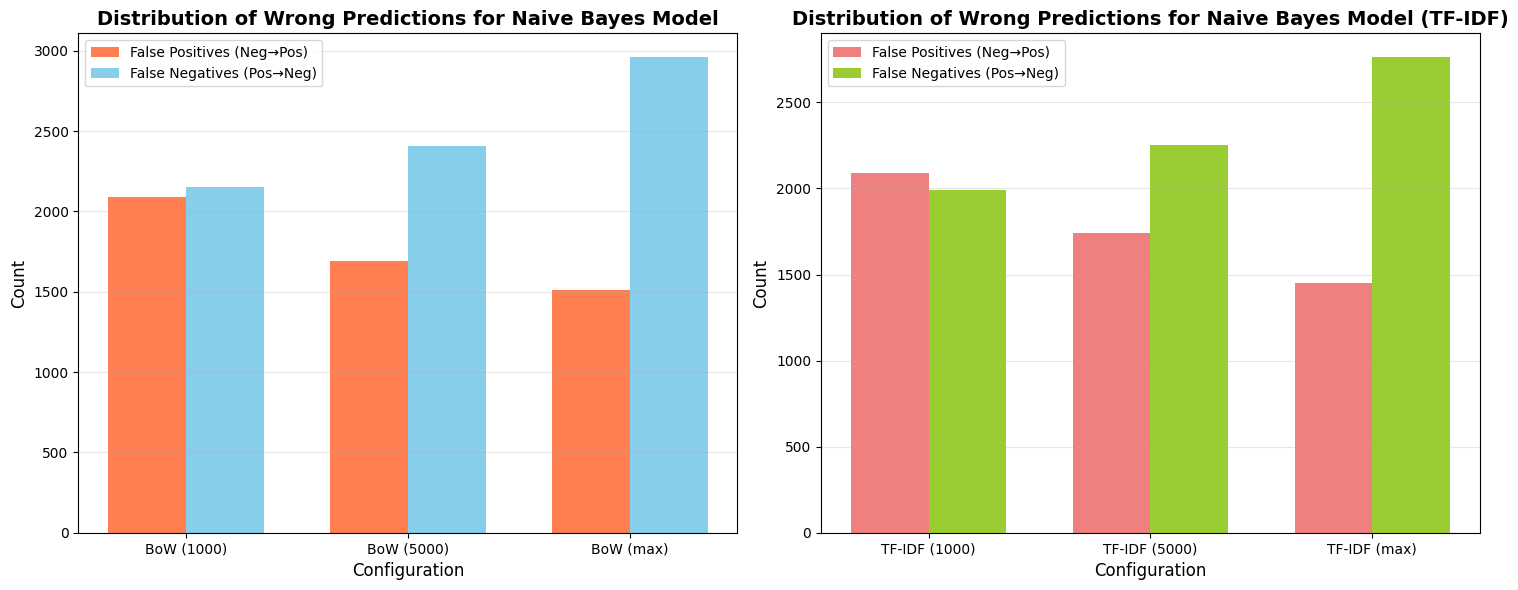

In [39]:
# Data for all three configurations
configs_bow = ['BoW (1000)', 'BoW (5000)', 'BoW (max)']
configs_tfidf = ['TF-IDF (1000)', 'TF-IDF (5000)', 'TF-IDF (max)']
fp_list_bow = []
fn_list_bow = []
fp_list_tfidf = []
fn_list_tfidf = []

for config in configs_bow:
    cm = results_nb_bow[config]['confusion_matrix']
    fp_list_bow.append(cm[0][1])  # False Positives
    fn_list_bow.append(cm[1][0])  # False Negatives

for config in configs_tfidf:
    cm = results_nb_tfidf[config]['confusion_matrix']
    fp_list_tfidf.append(cm[0][1])  # False Positives
    fn_list_tfidf.append(cm[1][0])  # False Negatives

# Create bar chart
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x = range(len(configs_bow))
width = 0.35

ax[0].bar([i - width/2 for i in x], fp_list_bow, width, label='False Positives (Neg→Pos)', color='coral')
ax[0].bar([i + width/2 for i in x], fn_list_bow, width, label='False Negatives (Pos→Neg)', color='skyblue')

ax[0].set_xlabel('Configuration', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Distribution of Wrong Predictions for Naive Bayes Model', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(configs_bow)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

ax[1].bar([i - width/2 for i in x], fp_list_tfidf, width, label='False Positives (Neg→Pos)', color='lightcoral')
ax[1].bar([i + width/2 for i in x], fn_list_tfidf, width, label='False Negatives (Pos→Neg)', color='yellowgreen')

ax[1].set_xlabel('Configuration', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_title('Distribution of Wrong Predictions for Naive Bayes Model (TF-IDF)', fontsize=14, fontweight='bold')
ax[1].set_xticks(x)
ax[1].set_xticklabels(configs_tfidf)
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

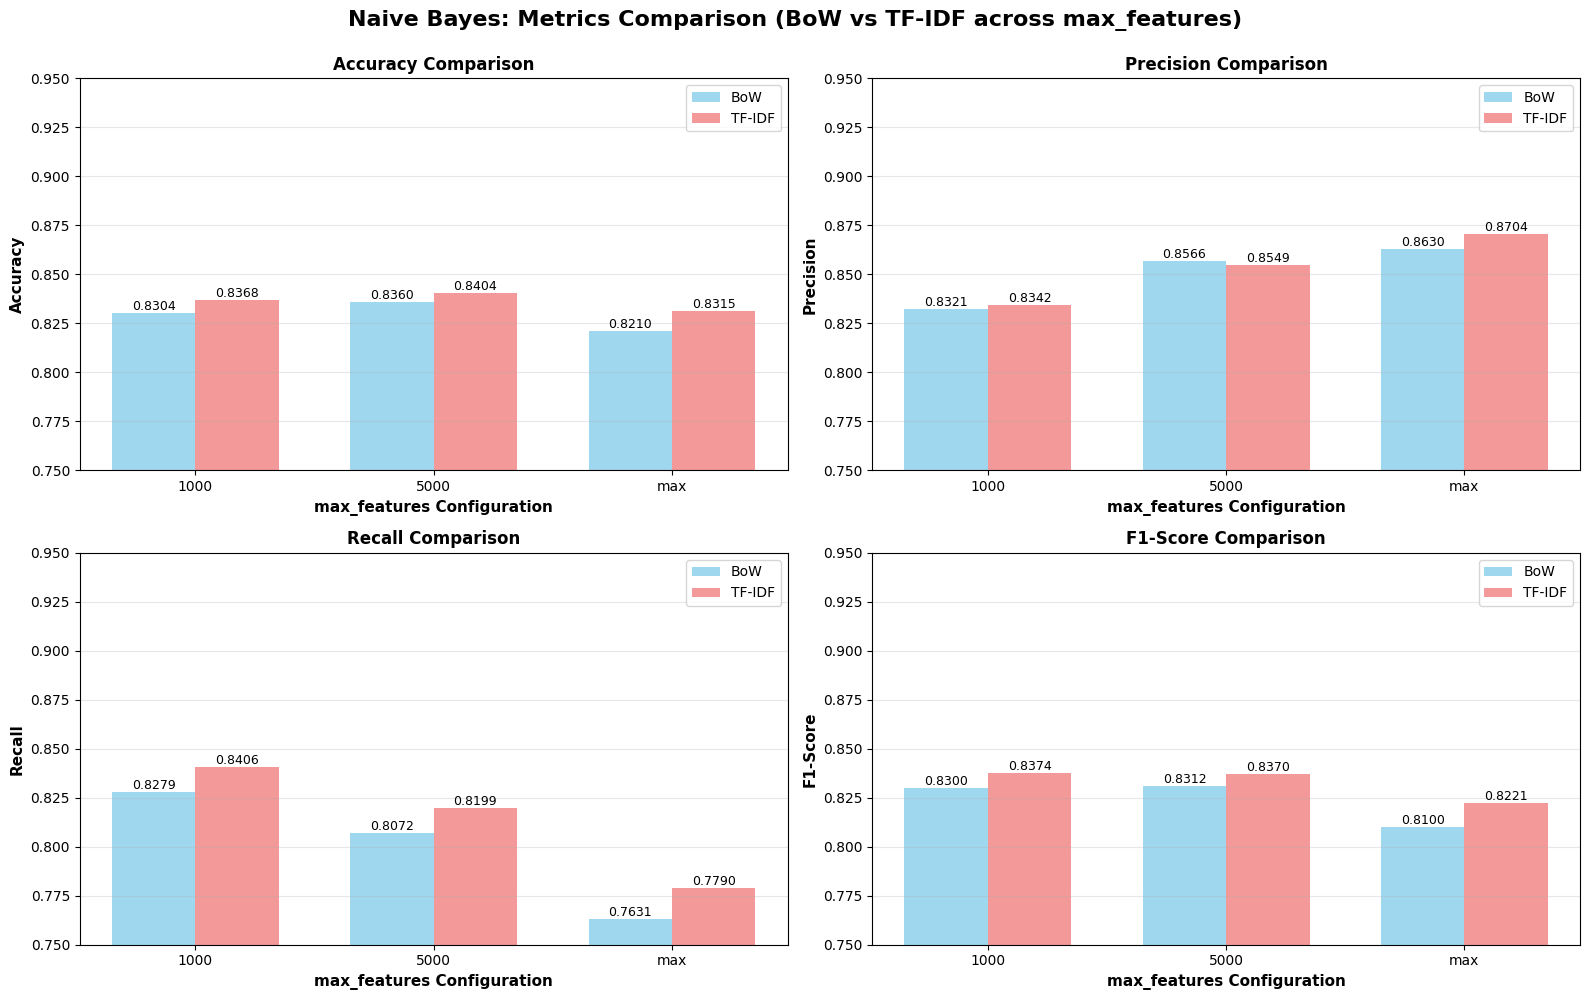

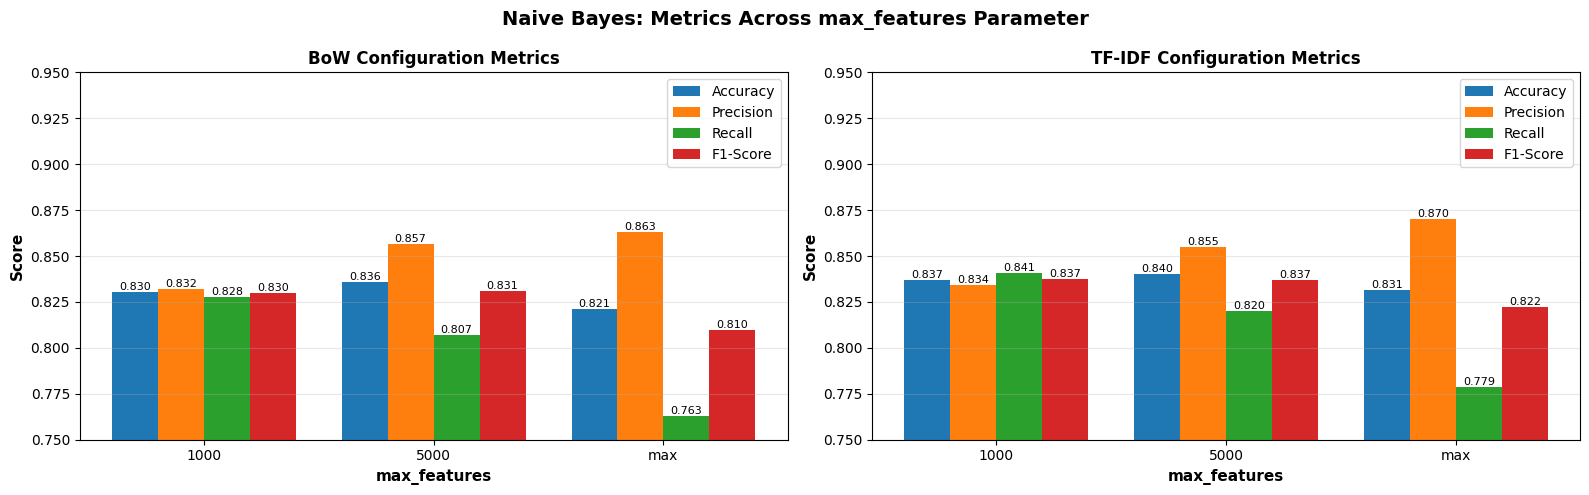


KEY INSIGHTS:


BoW Representation:
 > Best Accuracy: BoW (5000) (0.8360)
 > Best F1-Score: BoW (5000) (0.8312)
 > Best Recall: BoW (1000) (0.8279)

TF-IDF Representation:
 > Best Accuracy: TF-IDF (5000) (0.8404)
 > Best F1-Score: TF-IDF (1000) (0.8374)
 > Best Recall: TF-IDF (1000) (0.8406)


In [40]:
def compare_naive_bayes_metrics(results_bow, results_tfidf):
    """
    Create comprehensive visualizations comparing Naive Bayes metrics across
    BoW and TF-IDF representations for different max_features configurations.
    
    Parameters:
    - results_bow: Dictionary with BoW results (BoW (1000), BoW (5000), BoW (max))
    - results_tfidf: Dictionary with TF-IDF results (TF-IDF (1000), TF-IDF (5000), TF-IDF (max))
    
    Returns:
    - DataFrame with organized metrics for all configurations
    """
    
    # ========================================================================
    # Extract metrics from results
    # ========================================================================
    
    metrics_data = []
    
    # Process BoW configurations
    for config_name, config_data in results_bow.items():
        conf_matrix = config_data['confusion_matrix']
        accuracy = config_data['accuracy']
        
        # Extract confusion matrix values
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_data.append({
            'Configuration': config_name,
            'Representation': 'BoW',
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
    
    # Process TF-IDF configurations
    for config_name, config_data in results_tfidf.items():
        conf_matrix = config_data['confusion_matrix']
        accuracy = config_data['accuracy']
        
        # Extract confusion matrix values
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_data.append({
            'Configuration': config_name,
            'Representation': 'TF-IDF',
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
    
    metrics_df = pd.DataFrame(metrics_data)
    
    # ========================================================================
    # VISUALIZATION 1: Side-by-side metrics comparison (all metrics)
    # ========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Naive Bayes: Metrics Comparison (BoW vs TF-IDF across max_features)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Prepare data for plotting
        bow_data = metrics_df[metrics_df['Representation'] == 'BoW']
        tfidf_data = metrics_df[metrics_df['Representation'] == 'TF-IDF']
        
        x = np.arange(3)  # 3 configurations: 1000, 5000, max
        width = 0.35
        
        # Extract metric values (sorted by configuration size)
        bow_values = [bow_data[bow_data['Configuration'] == f'BoW {size}'][metric].values[0] 
                      for size in ['(1000)', '(5000)', '(max)']]
        tfidf_values = [tfidf_data[tfidf_data['Configuration'] == f'TF-IDF {size}'][metric].values[0] 
                        for size in ['(1000)', '(5000)', '(max)']]
        
        # Create bars
        bars1 = ax.bar(x - width/2, bow_values, width, label='BoW', color='skyblue', alpha=0.8)
        bars2 = ax.bar(x + width/2, tfidf_values, width, label='TF-IDF', color='lightcoral', alpha=0.8)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}',
                       ha='center', va='bottom', fontsize=9)
        
        # Customize subplot
        ax.set_xlabel('max_features Configuration', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{metric}', fontsize=11, fontweight='bold')
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(['1000', '5000', 'max'])
        ax.legend(fontsize=10)
        ax.set_ylim([0.75, 0.95])
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # VISUALIZATION 2: Metric comparison by representation type
    # ========================================================================
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Naive Bayes: Metrics Across max_features Parameter', 
                 fontsize=14, fontweight='bold')
    
    for idx, representation in enumerate(['BoW', 'TF-IDF']):
        ax = axes[idx]
        
        data = metrics_df[metrics_df['Representation'] == representation]
        configs = ['1000', '5000', 'max']
        
        # Extract all metrics
        accuracy_vals = [data[data['Configuration'] == f'{representation} ({c})']['Accuracy'].values[0] for c in configs]
        precision_vals = [data[data['Configuration'] == f'{representation} ({c})']['Precision'].values[0] for c in configs]
        recall_vals = [data[data['Configuration'] == f'{representation} ({c})']['Recall'].values[0] for c in configs]
        f1_vals = [data[data['Configuration'] == f'{representation} ({c})']['F1-Score'].values[0] for c in configs]
        
        x = np.arange(len(configs))
        width = 0.2
        
        bars1 = ax.bar(x - 1.5*width, accuracy_vals, width, label='Accuracy', color='#1f77b4')
        bars2 = ax.bar(x - 0.5*width, precision_vals, width, label='Precision', color='#ff7f0e')
        bars3 = ax.bar(x + 0.5*width, recall_vals, width, label='Recall', color='#2ca02c')
        bars4 = ax.bar(x + 1.5*width, f1_vals, width, label='F1-Score', color='#d62728')
        
        # Add value labels
        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=8)
        
        ax.set_xlabel('max_features', fontsize=11, fontweight='bold')
        ax.set_ylabel('Score', fontsize=11, fontweight='bold')
        ax.set_title(f'{representation} Configuration Metrics', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(configs)
        ax.legend(fontsize=10)
        ax.set_ylim([0.75, 0.95])
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # KEY INSIGHTS
    # ========================================================================
    
    print("\nKEY INSIGHTS:\n")
    
    # Best configuration for each metric and representation
    for representation in ['BoW', 'TF-IDF']:
        print(f"\n{representation} Representation:")
        rep_data = metrics_df[metrics_df['Representation'] == representation]
        
        best_accuracy_idx = rep_data['Accuracy'].idxmax()
        best_f1_idx = rep_data['F1-Score'].idxmax()
        
        print(f" > Best Accuracy: {rep_data.loc[best_accuracy_idx, 'Configuration']} "
              f"({rep_data.loc[best_accuracy_idx, 'Accuracy']:.4f})")
        print(f" > Best F1-Score: {rep_data.loc[best_f1_idx, 'Configuration']} "
              f"({rep_data.loc[best_f1_idx, 'F1-Score']:.4f})")
        print(f" > Best Recall: {rep_data.loc[rep_data['Recall'].idxmax(), 'Configuration']} "
              f"({rep_data.loc[rep_data['Recall'].idxmax(), 'Recall']:.4f})")
    
    return metrics_df

# Execute the comparison
metrics_comparison = compare_naive_bayes_metrics(results_nb_bow, results_nb_tfidf)


Let's analyze the result about **Naive Bayes** model for BoW and TF-IDF rerpresentation. As we mentioned, the `max_features` parameter changing three times for doing some tests.

1. `max_features=1000` **Results**:
    
    The **accuracy** is `0.8304`(BoW) and `0.8368` (TF-IDF) from 25000 samples (Test).That means that model can predict the following samples in total:

    - *Correct predictions (83,4%)*: 0.834 x 25000 $\approx$ 20850 samples correct
    - *Wrong predictions (16,6%)*: 0.166 x 25000 $\approx$ 4160 samples incorrect

    The **precision** for negative and positive class are `0.83` (BoW and TF-IDF) from 25000 samples (Test). That means our model can predict in the same way the both classes. The other `0.17` refers to *wrong predictions* influenced by false postive and negative predictions.


    The **recall** for negative and positive class are `0.83` (BoW and TF-IDF) from 25000 samples (Test). That means our model can predict in the same way the both classes.

    Both text representations has a good **F1-Score** that means `recall` and `precision` are not imabalace.



2. `max_features=5000` **Results**:
    
    The **accuracy** is `0.8304`(BoW) and `0.8404` (TF-IDF) from 25000 samples (Test).That means that model can predict the following samples in total:

    - *Correct predictions (83,6%)*: 0.8360 x 25000 $\approx$ 20900 samples correct
    - *Wrong predictions (16,4%)*: 0.164 x 25000 $\approx$ 4100 samples incorrect

    The **precision** for negative class is `0.82`(BoW) and `0.83` (TF-IDF) and for positive class are `0.86` (BoW) and `0.87` (TF-IDF) from 25000 samples (Test). That means our model can predict a bit better the positive class. The other `0.16` refers to *wrong predictions* influenced by false postive and negative predictions.

    The **recall** for negative class are `0.86` (BoW and TF-IDF) and positive class are `0.81` (BoW and TF-IDF) from 25000 samples (Test). For this case our model is better precise the negative rather than positive class. 

   Both text representations has a good **F1-Score** that means `recall` and `precision` are not imabalace.

3. `max_features=None` **Results**:
    
    The **accuracy** is `0.8210` (BoW) and `0.8315` (TF-IDF) from 25000 samples (Test).That means that model can predict the following samples in total:

    - *Correct predictions (82,1%)*: 0.8210 x 25000 $\approx$ 20525 samples correct
    - *Wrong predictions (17,9%)*: 0.179 x 25000 $\approx$ 4475 samples incorrect

    The **precision** for negative class is `0.79` (BoW) and `0.8` (TF-IDF) and for positive class are `0.86` (BoW) and `0.87` (TF-IDF) from 25000 samples (Test). That means our model can predict better the positive class. The other `0.17` refers to *wrong predictions* influenced by false postive and negative predictions.

    The **recall** for negative class are `0.88` for both text representation and positive class are `0.76` (BoW) and `0.78` (TF-IDF) from 25000 samples (Test). For this case our model is better precise the negative rather than positive class. 

    Both text representations has a good **F1-Score** that means `recall` and `precision` are not imabalace.

---

**My Analisis**

**About accurary:** In the graph of Distribution about *Wrong Predictions* we can see that the *False Negatives* grow and the *Flase Positives* shrink when consider more number of words for BoW. This show us that the Naive Bayes Model starts failed to identified correctly the negative reviews. 

The reason isn't clear, but my hypothesis is that, with larger vocabularies, the model is affected by dimensionality combined with dispersion. The signal-to-noise ratio decreases, and smoothing causes the model to favor the class with a more varied vocabulary.

**About precision and recall:** Is interesting that Naive Bayes Model decreases their precision and increase their recall in the negative class with more `features` considered in the BoW. This characteristic have correlation with the False Positive predictions that we discuted above. The reasons are the same with more dimensionality and dispersion, is difficult to Naive Bayes treat the noise of have more rare words in positive reviews.

**About text representation:** Using BoW of TF-IDF made no difference between the text representation on the metrics when we using Naive-Bayes model as classifier. Have less changes such as 0.1 between models.

#### **Logistic Regression model**

Now let's try with the same distribution. The TF-IDF and BoW representation and compare the metrics.

In [41]:
from sklearn.linear_model import LogisticRegression


LOGISTIC REGRESSION - BoW (1000)

Accuracy: 0.8554

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.86      0.85      0.85     12500
Positive (1)       0.85      0.86      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


LOGISTIC REGRESSION - BoW (5000)

Accuracy: 0.8490

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.84      0.86      0.85     12500
Positive (1)       0.86      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000


LOGISTIC REGRESSION - BoW (max)

Accuracy: 0.8618

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.86      0.87      0.86     12500
Positive (

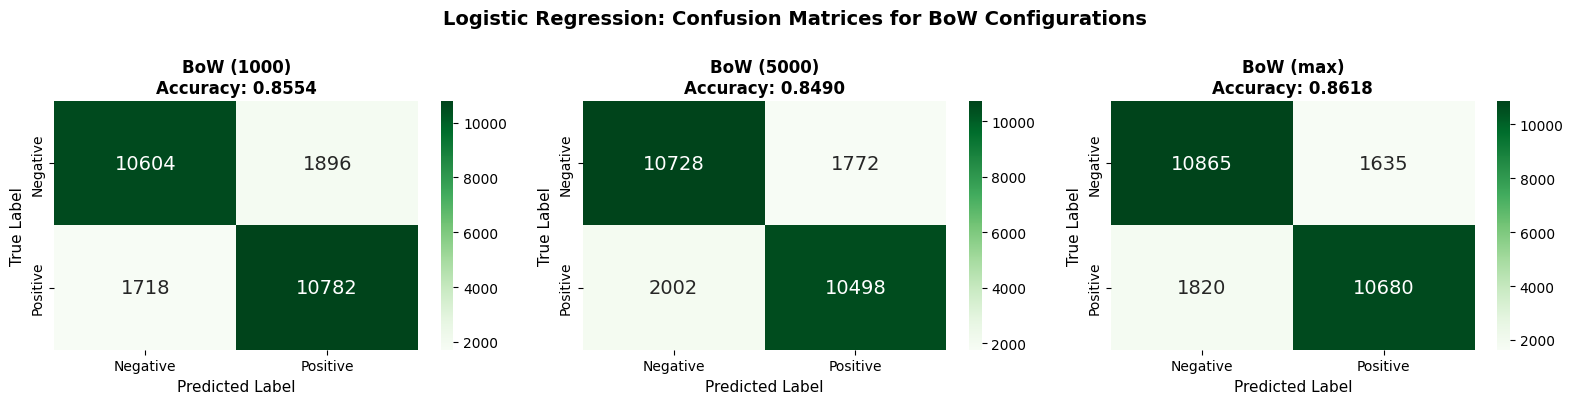


COMPARISON SUMMARY: LOGISTIC REGRESSION ON BoW CONFIGURATIONS

Configuration Accuracy Precision (Pos) Recall (Pos) F1-Score (Pos)    TP    TN   FP   FN
   BoW (1000)   0.8554          0.8504       0.8626         0.8565 10782 10604 1896 1718
   BoW (5000)   0.8490          0.8556       0.8398         0.8476 10498 10728 1772 2002
    BoW (max)   0.8618          0.8672       0.8544         0.8608 10680 10865 1635 1820



In [42]:
def evaluate_logistic_regression_bow_configurations(
    X_train_1000, X_test_1000, 
    X_train_5000, X_test_5000, 
    X_train_max, X_test_max, 
    y_train, y_test
):
    """
    Train and evaluate Logistic Regression on three BoW configurations.
    
    Parameters:
    - X_train_1000, X_test_1000: BoW features with 1000 max_features
    - X_train_5000, X_test_5000: BoW features with 5000 max_features
    - X_train_max, X_test_max: BoW features with no limit
    - y_train, y_test: Labels
    
    Returns:
    - Dictionary with models, predictions, and metrics
    """
    
    results = {}
    configurations = [
        ('BoW (1000)', X_train_1000, X_test_1000),
        ('BoW (5000)', X_train_5000, X_test_5000),
        ('BoW (max)', X_train_max, X_test_max)
    ]
    
    # Train and evaluate for each configuration
    for config_name, X_train, X_test in configurations:
        print("\n" + "="*80)
        print(f"LOGISTIC REGRESSION - {config_name}")
        print("="*80)
        
        # Create and train model
        # max_iter increased to ensure convergence with large feature sets
        model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        # Store results
        results[config_name] = {
            'model': model,
            'y_pred': y_pred,
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'X_test': X_test
        }
        
        # Print accuracy
        print(f"\nAccuracy: {accuracy:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=['Negative (0)', 'Positive (1)']))
    
    # ========================================================================
    # VISUALIZATION: Confusion Matrices
    # ========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    for idx, (config_name, _, _) in enumerate(configurations):
        conf_matrix = results[config_name]['confusion_matrix']
        
        sns.heatmap(conf_matrix, 
                    annot=True, 
                    fmt='d', 
                    cmap='Greens',
                    cbar=True,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'],
                    ax=axes[idx],
                    annot_kws={'fontsize': 14})
        
        accuracy = results[config_name]['accuracy']
        axes[idx].set_title(f'{config_name}\nAccuracy: {accuracy:.4f}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=11)
        axes[idx].set_xlabel('Predicted Label', fontsize=11)
    
    plt.suptitle('Logistic Regression: Confusion Matrices for BoW Configurations', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # COMPARISON TABLE
    # ========================================================================
    print("\n" + "="*80)
    print("COMPARISON SUMMARY: LOGISTIC REGRESSION ON BoW CONFIGURATIONS")
    print("="*80 + "\n")
    
    comparison_data = []
    for config_name, _, _ in configurations:
        conf_matrix = results[config_name]['confusion_matrix']
        accuracy = results[config_name]['accuracy']
        
        # Calculate additional metrics
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Precision, Recall, F1 for positive class
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        comparison_data.append({
            'Configuration': config_name,
            'Accuracy': f'{accuracy:.4f}',
            'Precision (Pos)': f'{precision:.4f}',
            'Recall (Pos)': f'{recall:.4f}',
            'F1-Score (Pos)': f'{f1:.4f}',
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    
    return results

# Execute the function
results_lr_bow = evaluate_logistic_regression_bow_configurations(
    X_train_bow_1000, X_test_bow_1000,
    X_train_bow_5000, X_test_bow_5000,
    X_train_bow_max, X_test_bow_max,
    df_train['label'], df_test['label']
)


LOGISTIC REGRESSION - TF-IDF (1000)

Accuracy: 0.8585

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.86      0.85      0.86     12500
Positive (1)       0.85      0.87      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


LOGISTIC REGRESSION - TF-IDF (5000)

Accuracy: 0.8794

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.88      0.88      0.88     12500
Positive (1)       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000


LOGISTIC REGRESSION - TF-IDF (max)

Accuracy: 0.8820

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.88      0.88      0.88     12500
P

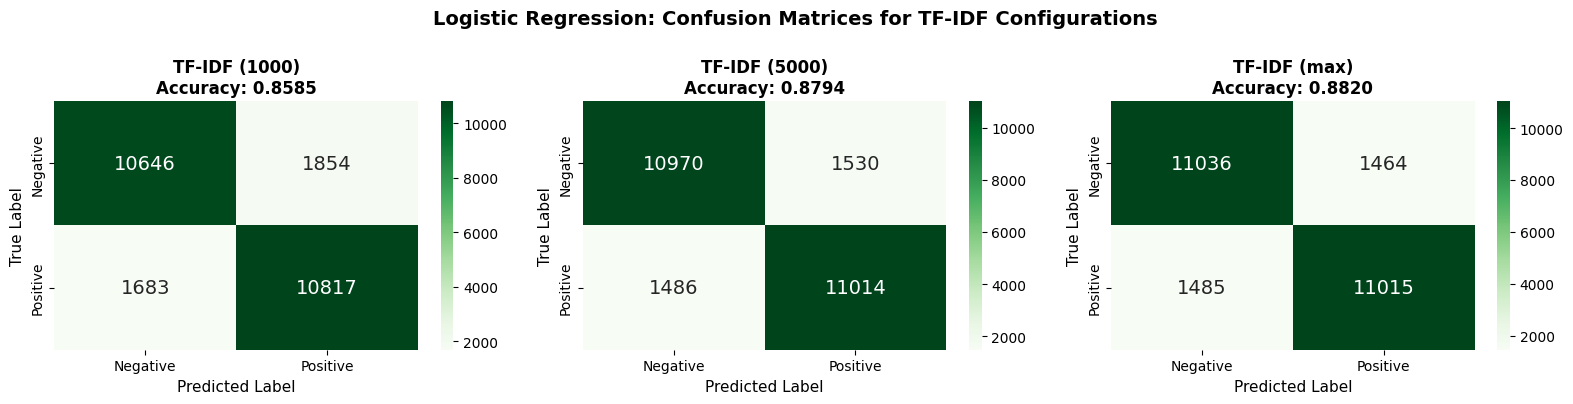


COMPARISON SUMMARY: LOGISTIC REGRESSION ON TF-IDF CONFIGURATIONS

Configuration Accuracy Precision (Pos) Recall (Pos) F1-Score (Pos)    TP    TN   FP   FN
TF-IDF (1000)   0.8585          0.8537       0.8654         0.8595 10817 10646 1854 1683
TF-IDF (5000)   0.8794          0.8780       0.8811         0.8796 11014 10970 1530 1486
 TF-IDF (max)   0.8820          0.8827       0.8812         0.8819 11015 11036 1464 1485



In [43]:
def evaluate_logistic_regression_tfidf_configurations(
    X_train_1000, X_test_1000, 
    X_train_5000, X_test_5000, 
    X_train_max, X_test_max, 
    y_train, y_test
):
    """
    Train and evaluate Logistic Regression on three TF-IDF configurations.
    
    Parameters:
    - X_train_1000, X_test_1000: TF-IDF features with 1000 max_features
    - X_train_5000, X_test_5000: TF-IDF features with 5000 max_features
    - X_train_max, X_test_max: TF-IDF features with no limit
    - y_train, y_test: Labels
    
    Returns:
    - Dictionary with models, predictions, and metrics
    """
    
    results = {}
    configurations = [
        ('TF-IDF (1000)', X_train_1000, X_test_1000),
        ('TF-IDF (5000)', X_train_5000, X_test_5000),
        ('TF-IDF (max)', X_train_max, X_test_max)
    ]
    
    # Train and evaluate for each configuration
    for config_name, X_train, X_test in configurations:
        print("\n" + "="*80)
        print(f"LOGISTIC REGRESSION - {config_name}")
        print("="*80)
        
        # Create and train model
        # max_iter increased to ensure convergence with large feature sets
        model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        
        # Store results
        results[config_name] = {
            'model': model,
            'y_pred': y_pred,
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'X_test': X_test
        }
        
        # Print accuracy
        print(f"\nAccuracy: {accuracy:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, 
                                   target_names=['Negative (0)', 'Positive (1)']))
    
    # ========================================================================
    # VISUALIZATION: Confusion Matrices
    # ========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    for idx, (config_name, _, _) in enumerate(configurations):
        conf_matrix = results[config_name]['confusion_matrix']
        
        sns.heatmap(conf_matrix, 
                    annot=True, 
                    fmt='d', 
                    cmap='Greens',
                    cbar=True,
                    xticklabels=['Negative', 'Positive'],
                    yticklabels=['Negative', 'Positive'],
                    ax=axes[idx],
                    annot_kws={'fontsize': 14})
        
        accuracy = results[config_name]['accuracy']
        axes[idx].set_title(f'{config_name}\nAccuracy: {accuracy:.4f}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=11)
        axes[idx].set_xlabel('Predicted Label', fontsize=11)
    
    plt.suptitle('Logistic Regression: Confusion Matrices for TF-IDF Configurations', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # COMPARISON TABLE
    # ========================================================================
    print("\n" + "="*80)
    print("COMPARISON SUMMARY: LOGISTIC REGRESSION ON TF-IDF CONFIGURATIONS")
    print("="*80 + "\n")
    
    comparison_data = []
    for config_name, _, _ in configurations:
        conf_matrix = results[config_name]['confusion_matrix']
        accuracy = results[config_name]['accuracy']
        
        # Calculate additional metrics
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Precision, Recall, F1 for positive class
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        comparison_data.append({
            'Configuration': config_name,
            'Accuracy': f'{accuracy:.4f}',
            'Precision (Pos)': f'{precision:.4f}',
            'Recall (Pos)': f'{recall:.4f}',
            'F1-Score (Pos)': f'{f1:.4f}',
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    
    return results

# Execute the function
results_lr_tfidf = evaluate_logistic_regression_tfidf_configurations(
    X_train_tfidf_1000, X_test_tfidf_1000,
    X_train_tfidf_5000, X_test_tfidf_5000,
    X_train_tfidf_max, X_test_tfidf_max,
    df_train['label'], df_test['label']
)

In [44]:
# Execute for Logisitic Regression BoW
print("="*115)
print("WRONG PREDICTIONS SUMMARY - LOGISTIC REGRESSION (BOW)")
print("="*115 + "\n")

summary_table = get_wrong_predictions_summary(results_lr_bow)
print(summary_table.to_string(index=False))
print("\n" + "="*115)

WRONG PREDICTIONS SUMMARY - LOGISTIC REGRESSION (BOW)

Configuration  True Positives  True Negatives  False Positives  False Negatives  FP %  FN %  Total Wrong T Wrong %
   BoW (1000)           10782           10604             1896             1718 52.5% 47.5%         3614     14.5%
   BoW (5000)           10498           10728             1772             2002 47.0% 53.0%         3774     15.1%
    BoW (max)           10680           10865             1635             1820 47.3% 52.7%         3455     13.8%



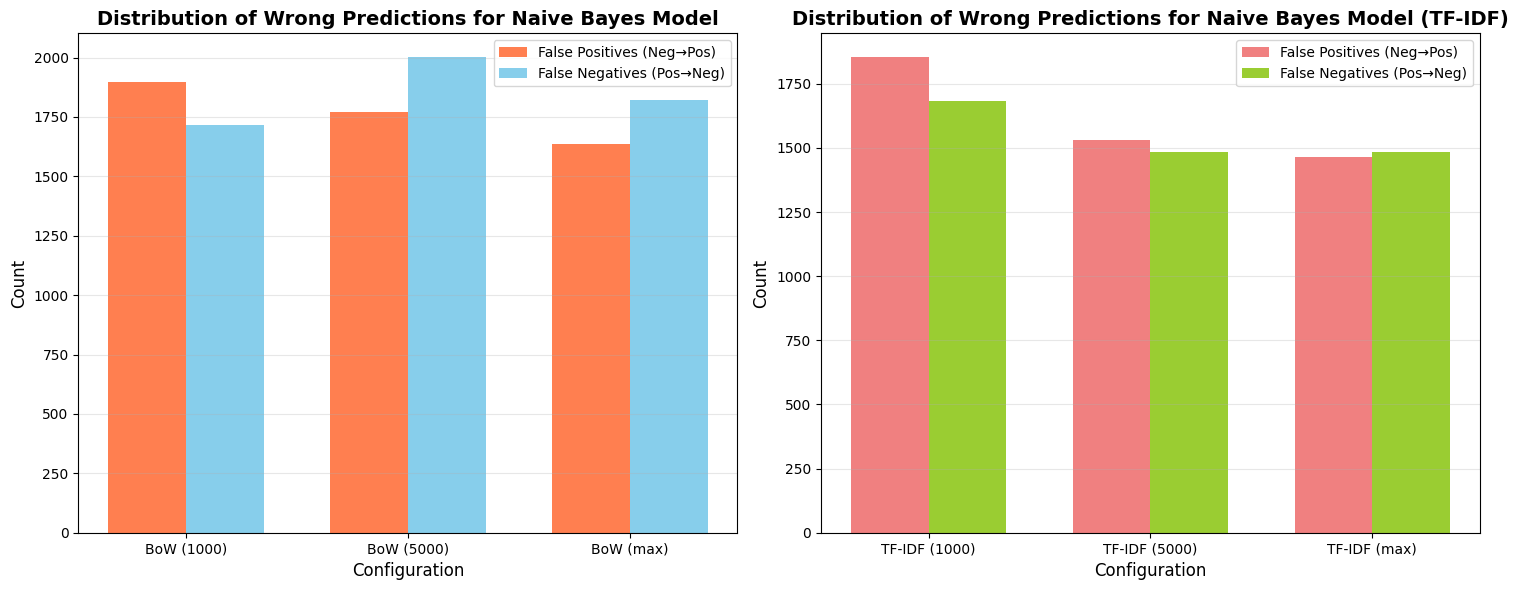

In [45]:
# Data for all three configurations
configs_bow = ['BoW (1000)', 'BoW (5000)', 'BoW (max)']
configs_tfidf = ['TF-IDF (1000)', 'TF-IDF (5000)', 'TF-IDF (max)']
fp_list_bow = []
fn_list_bow = []
fp_list_tfidf = []
fn_list_tfidf = []

for config in configs_bow:
    cm = results_lr_bow[config]['confusion_matrix']
    fp_list_bow.append(cm[0][1])  # False Positives
    fn_list_bow.append(cm[1][0])  # False Negatives

for config in configs_tfidf:
    cm = results_lr_tfidf[config]['confusion_matrix']
    fp_list_tfidf.append(cm[0][1])  # False Positives
    fn_list_tfidf.append(cm[1][0])  # False Negatives

# Create bar chart
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
x = range(len(configs_bow))
width = 0.35

ax[0].bar([i - width/2 for i in x], fp_list_bow, width, label='False Positives (Neg→Pos)', color='coral')
ax[0].bar([i + width/2 for i in x], fn_list_bow, width, label='False Negatives (Pos→Neg)', color='skyblue')

ax[0].set_xlabel('Configuration', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_title('Distribution of Wrong Predictions for Naive Bayes Model', fontsize=14, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(configs_bow)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

ax[1].bar([i - width/2 for i in x], fp_list_tfidf, width, label='False Positives (Neg→Pos)', color='lightcoral')
ax[1].bar([i + width/2 for i in x], fn_list_tfidf, width, label='False Negatives (Pos→Neg)', color='yellowgreen')

ax[1].set_xlabel('Configuration', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_title('Distribution of Wrong Predictions for Naive Bayes Model (TF-IDF)', fontsize=14, fontweight='bold')
ax[1].set_xticks(x)
ax[1].set_xticklabels(configs_tfidf)
ax[1].legend()
ax[1].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

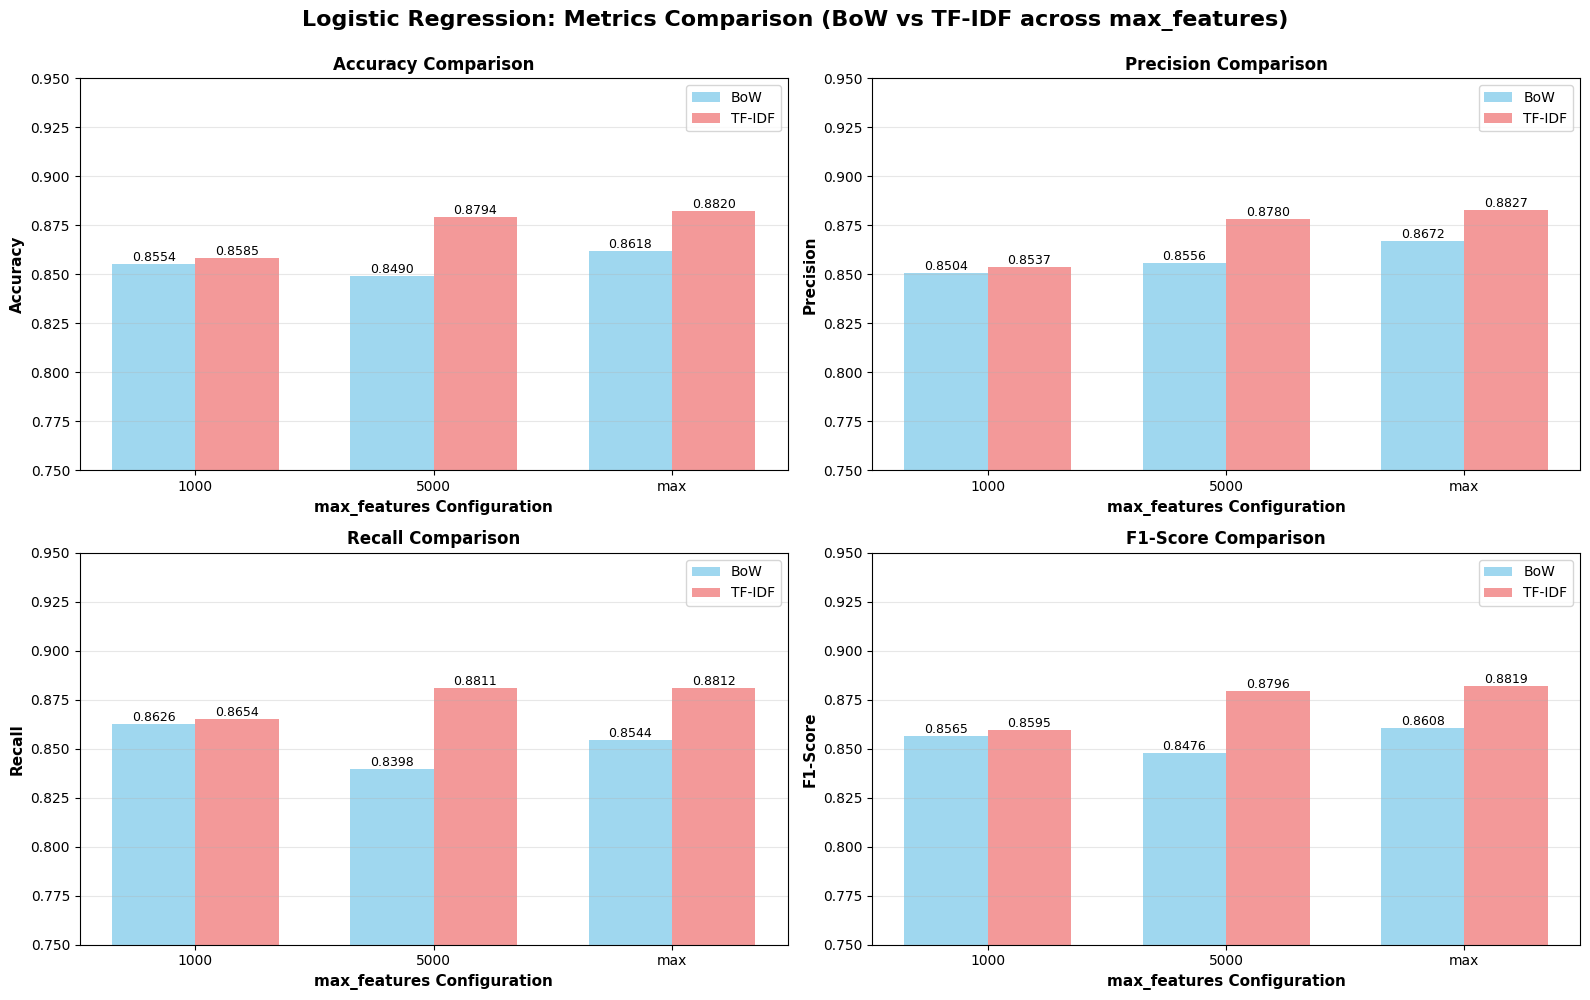

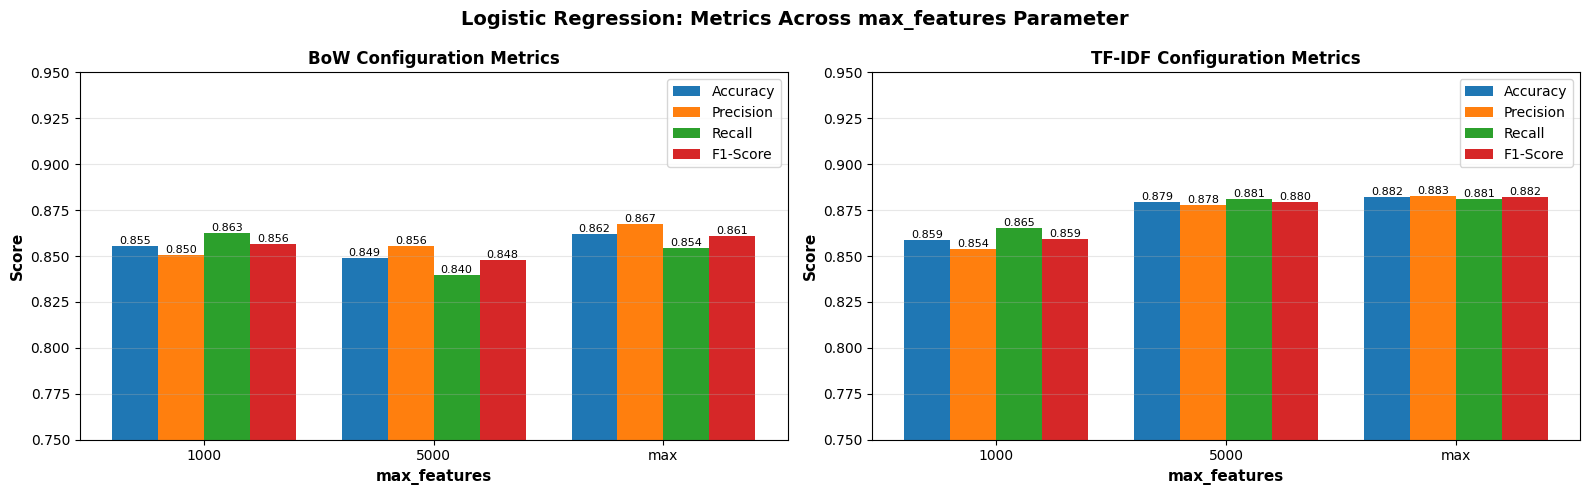


KEY INSIGHTS:


BoW Representation:
 > Best Accuracy: BoW (max) (0.8618)
 > Best F1-Score: BoW (max) (0.8608)
 > Best Recall: BoW (1000) (0.8626)

TF-IDF Representation:
 > Best Accuracy: TF-IDF (max) (0.8820)
 > Best F1-Score: TF-IDF (max) (0.8819)
 > Best Recall: TF-IDF (max) (0.8812)


In [46]:
def compare_logistic_regression_metrics(results_bow, results_tfidf):
    """
    Create comprehensive visualizations comparing Logistic Regression metrics across
    BoW and TF-IDF representations for different max_features configurations.
    
    Parameters:
    - results_bow: Dictionary with BoW results (BoW (1000), BoW (5000), BoW (max))
    - results_tfidf: Dictionary with TF-IDF results (TF-IDF (1000), TF-IDF (5000), TF-IDF (max))
    
    Returns:
    - DataFrame with organized metrics for all configurations
    """
    
    # ========================================================================
    # Extract metrics from results
    # ========================================================================
    
    metrics_data = []
    
    # Process BoW configurations
    for config_name, config_data in results_bow.items():
        conf_matrix = config_data['confusion_matrix']
        accuracy = config_data['accuracy']
        
        # Extract confusion matrix values
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_data.append({
            'Configuration': config_name,
            'Representation': 'BoW',
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
    
    # Process TF-IDF configurations
    for config_name, config_data in results_tfidf.items():
        conf_matrix = config_data['confusion_matrix']
        accuracy = config_data['accuracy']
        
        # Extract confusion matrix values
        tn, fp, fn, tp = conf_matrix[0][0], conf_matrix[0][1], conf_matrix[1][0], conf_matrix[1][1]
        
        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics_data.append({
            'Configuration': config_name,
            'Representation': 'TF-IDF',
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        })
    
    metrics_df = pd.DataFrame(metrics_data)
    
    # ========================================================================
    # VISUALIZATION 1: Side-by-side metrics comparison (all metrics)
    # ========================================================================
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Logistic Regression: Metrics Comparison (BoW vs TF-IDF across max_features)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Prepare data for plotting
        bow_data = metrics_df[metrics_df['Representation'] == 'BoW']
        tfidf_data = metrics_df[metrics_df['Representation'] == 'TF-IDF']
        
        x = np.arange(3)  # 3 configurations: 1000, 5000, max
        width = 0.35
        
        # Extract metric values (sorted by configuration size)
        bow_values = [bow_data[bow_data['Configuration'] == f'BoW {size}'][metric].values[0] 
                      for size in ['(1000)', '(5000)', '(max)']]
        tfidf_values = [tfidf_data[tfidf_data['Configuration'] == f'TF-IDF {size}'][metric].values[0] 
                        for size in ['(1000)', '(5000)', '(max)']]
        
        # Create bars
        bars1 = ax.bar(x - width/2, bow_values, width, label='BoW', color='skyblue', alpha=0.8)
        bars2 = ax.bar(x + width/2, tfidf_values, width, label='TF-IDF', color='lightcoral', alpha=0.8)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}',
                       ha='center', va='bottom', fontsize=9)
        
        # Customize subplot
        ax.set_xlabel('max_features Configuration', fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{metric}', fontsize=11, fontweight='bold')
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(['1000', '5000', 'max'])
        ax.legend(fontsize=10)
        ax.set_ylim([0.75, 0.95])
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # VISUALIZATION 2: Metric comparison by representation type
    # ========================================================================
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Logistic Regression: Metrics Across max_features Parameter', 
                 fontsize=14, fontweight='bold')
    
    for idx, representation in enumerate(['BoW', 'TF-IDF']):
        ax = axes[idx]
        
        data = metrics_df[metrics_df['Representation'] == representation]
        configs = ['1000', '5000', 'max']
        
        # Extract all metrics
        accuracy_vals = [data[data['Configuration'] == f'{representation} ({c})']['Accuracy'].values[0] for c in configs]
        precision_vals = [data[data['Configuration'] == f'{representation} ({c})']['Precision'].values[0] for c in configs]
        recall_vals = [data[data['Configuration'] == f'{representation} ({c})']['Recall'].values[0] for c in configs]
        f1_vals = [data[data['Configuration'] == f'{representation} ({c})']['F1-Score'].values[0] for c in configs]
        
        x = np.arange(len(configs))
        width = 0.2
        
        bars1 = ax.bar(x - 1.5*width, accuracy_vals, width, label='Accuracy', color='#1f77b4')
        bars2 = ax.bar(x - 0.5*width, precision_vals, width, label='Precision', color='#ff7f0e')
        bars3 = ax.bar(x + 0.5*width, recall_vals, width, label='Recall', color='#2ca02c')
        bars4 = ax.bar(x + 1.5*width, f1_vals, width, label='F1-Score', color='#d62728')
        
        # Add value labels
        for bars in [bars1, bars2, bars3, bars4]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}',
                       ha='center', va='bottom', fontsize=8)
        
        ax.set_xlabel('max_features', fontsize=11, fontweight='bold')
        ax.set_ylabel('Score', fontsize=11, fontweight='bold')
        ax.set_title(f'{representation} Configuration Metrics', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(configs)
        ax.legend(fontsize=10)
        ax.set_ylim([0.75, 0.95])
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # KEY INSIGHTS
    # ========================================================================
    
    print("\nKEY INSIGHTS:\n")
    
    # Best configuration for each metric and representationS
    for representation in ['BoW', 'TF-IDF']:
        print(f"\n{representation} Representation:")
        rep_data = metrics_df[metrics_df['Representation'] == representation]
        
        best_accuracy_idx = rep_data['Accuracy'].idxmax()
        best_f1_idx = rep_data['F1-Score'].idxmax()
        
        print(f" > Best Accuracy: {rep_data.loc[best_accuracy_idx, 'Configuration']} "
              f"({rep_data.loc[best_accuracy_idx, 'Accuracy']:.4f})")
        print(f" > Best F1-Score: {rep_data.loc[best_f1_idx, 'Configuration']} "
              f"({rep_data.loc[best_f1_idx, 'F1-Score']:.4f})")
        print(f" > Best Recall: {rep_data.loc[rep_data['Recall'].idxmax(), 'Configuration']} "
              f"({rep_data.loc[rep_data['Recall'].idxmax(), 'Recall']:.4f})")
    
    return metrics_df

# Execute the comparison
metrics_comparison = compare_logistic_regression_metrics(results_lr_bow, results_lr_tfidf)

Let's analyze the result about **Naive Bayes** model for BoW and TF-IDF rerpresentation. As we mentioned, the `max_features` parameter changing three times for doing some tests.

1. `max_features=1000` **Results**:
    
    The **accuracy** is `0.85544`(BoW) and `0.8585` (TF-IDF) from 25000 samples (Test).That means that model can predict the following samples in total:

    The **precision** for negative are `0.86` (BoW and TF-IDF) and `0.85` (Bow and TF-IDF) for positive class from 25000 samples (Test). That means our model can predict in the same way the both classes. The other `0.14` refers to *wrong predictions* influenced by false postive and negative predictions.


    The **recall** for negative and positive class are `0.86` (BoW and TF-IDF) from 25000 samples (Test). That means our model can predict in the same way the both classes.

    Both text representations has a good **F1-Score** that means `recall` and `precision` are not imabalace.



2. `max_features=5000` **Results**:
    
    The **accuracy** is `0.8490`(BoW) and `0.8794` (TF-IDF) from 25000 samples (Test).That means that model can predict the following samples in total:

    The **precision** for negative and positive class is `0.85`(BoW) and  `0.88` (TF-IDF) from 25000 samples (Test). That means our model can predict a bit better the positive class.

    The **recall** for both classes are `0.86` (BoW) and `0.88` (TF-IDF) from 25000 samples (Test). For this case our model is better precise the negative rather than positive class. 

   Both text representations has a good **F1-Score** that means `recall` and `precision` are not imabalace.

3. `max_features=None` **Results**:
    
    The **accuracy** is `0.8618` (BoW) and `0.8820` (TF-IDF) from 25000 samples (Test).That means that model can predict the following samples in total:

    The **precision** for both classes are `0.88` (BoW and TF-IDF) from 25000 samples (Test). That means our model can predict better the positive class.

    The **recall** for both classes are `0.88` for both text representation (Bow and TF-IDF).

    Both text representations has a good **F1-Score** that means `recall` and `precision` are not imabalace.

**My Analysis about comparion between Logistic Regression and Naive Bayes**

Give the results, we can infer that the best model between Naive-Bayes and Logistic Regression is the second. Why? My hypothesis is that Naive-Bayes is based on probabilities and the frecuency of the words with the TF-IDF, and for that reason is difficult to learn complex realtionships in the different reviews. However with Logistic Regression we have better results on all metrics, thanks to that the normalized weights and usin the probability of sigmoid function is useful for our model learn the complex relationships betweeen words to predict a good o bad review.

**Congrats to Logisitic Regression Model is the winner!! :)!**

## Part 2: Word Embeddings
---

### Pre-trained Embeddings

I decided to use Glove as a pretrained embedding. These two pre-trained models produce static embeddings, it means don't understand well the context of the text, only produces embeddings for each token.

**Glove pre-trained embedding model**

In [100]:
import urllib.request
import os
from nltk.tokenize import word_tokenize

# Download GloVe vectors (6B tokens, 100-dim)
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_file = "glove.6B.100d.txt"

# Download if not exists
if not os.path.exists(glove_file):
    print("Downloading GloVe vectors...")
    urllib.request.urlretrieve(glove_url, "glove.6B.zip")
    import zipfile
    with zipfile.ZipFile("glove.6B.zip", 'r') as zip_ref:
        zip_ref.extractall()

# Load GloVe vectors into memory
def load_glove_vectors(filepath):
    """Load GloVe vectors from Stanford"""
    embeddings_index = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_vectors = load_glove_vectors(glove_file)
print(f"Loaded {len(glove_vectors)} word vectors")

# Get embeddings for documents
def get_glove_embedding(text, embedding_size=100):
    """Get document embedding by averaging GloVe vectors"""
    tokens = word_tokenize(text)
    
    vectors = []
    for token in tokens:
        if token in glove_vectors:
            vectors.append(glove_vectors[token])
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(embedding_size)

# Apply to dataset
embeddings_glove = np.array([get_glove_embedding(text) for text in df_train['text_no_stopwords']])
embeddings_glove_test = np.array([get_glove_embedding(text) for text in df_test['text_no_stopwords']])

Loaded 400000 word vectors


In [101]:
df_train['embedding_glove'] = list(embeddings_glove)
df_test['embedding_glove'] = list(embeddings_glove_test)

In [102]:
df_train.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow
23664,"Nicely done, and along with ""New voyages"" it's...",1,"nicely done, and along with ""new voyages"" it's...","nicely done, along ""new voyages"" great continu...","nicely done, along ""new voyages"" great continu...","[nicely, done, ,, along, ``, new, voyages, '',...","[nice, ly, Ġdone, ,, Ġalong, Ġ"", new, Ġvoy, ag...","[-0.23950665, 0.30742177, 0.3617271, -0.278009...","[-0.23950673180944776, 0.3074219040977033, 0.3..."
17269,Despite some reviews being distinctly Luke-war...,1,despite some reviews being distinctly luke-war...,"despite reviews distinctly luke-warm, found st...","despite review distinctly luke-warm, found sto...","[despite, review, distinctly, luke-warm, ,, fo...","[despite, Ġreview, Ġdistinctly, Ġl, uke, -, wa...","[-0.08961326, 0.12934558, 0.32953262, -0.16765...","[-0.08961326741229962, 0.12934564599965917, 0...."
7551,"Very, very humdrum movie fare here with Stella...",0,"very, very humdrum movie fare here with stella...","very, humdrum movie fare stella stevens taking...","very, humdrum movie fare stella stevens taking...","[very, ,, humdrum, movie, fare, stella, steven...","[very, ,, Ġhum, d, rum, Ġmovie, Ġfare, Ġst, el...","[-0.0077177496, 0.13909286, 0.36063954, -0.302...","[-0.0077177571921466705, 0.13909286285146466, ..."
10064,I just saw the movie in theater. The movie has...,0,i just saw the movie in theater. the movie has...,saw movie theater. movie good points talk abou...,saw movie theater. movie good point talk about...,"[saw, movie, theater, ., movie, good, point, t...","[saw, Ġmovie, Ġtheater, ., Ġmovie, Ġgood, Ġpoi...","[-0.06966101, 0.17938295, 0.38182825, -0.27056...","[-0.06966101247977526, 0.17938300925552061, 0...."
399,"Imagine you're a high-school boy, in the back ...",0,"imagine you're a high-school boy, in the back ...","imagine high-school boy, back dark, uncrowded ...","imagine high-school boy, back dark, uncrowded ...","[imagine, high-school, boy, ,, back, dark, ,, ...","[im, agine, Ġhigh, -, school, Ġboy, ,, Ġback, ...","[0.041525107, 0.13933308, 0.45834088, -0.36953...","[0.04152510490268469, 0.13933307779952883, 0.4..."
23733,"George Raft as Steve Brodie, the carefree, dan...",1,"george raft as steve brodie, the carefree, dan...","george raft steve brodie, carefree, dancing ga...","george raft steve brodie, carefree, dancing ga...","[george, raft, steve, brodie, ,, carefree, ,, ...","[ge, orge, Ġraft, Ġste, ve, Ġbro, die, ,, Ġcar...","[-0.04623745, 0.14544058, 0.23898065, -0.25244...","[-0.046237475986000955, 0.14544050384791116, 0..."
8017,It's hard to tell if Noonan and Marshall are t...,0,it's hard to tell if noonan and marshall are t...,hard tell noonan marshall trying ape abbott & ...,hard tell noonan marshall trying ape abbott & ...,"[hard, tell, noonan, marshall, trying, ape, ab...","[hard, Ġtell, Ġnoon, an, Ġmarsh, all, Ġtrying,...","[-0.020507144, 0.17285892, 0.36925995, -0.3814...","[-0.02050714604035072, 0.17285879051971048, 0...."


In [103]:
df_test.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow
10839,The plot has something about white hunters cap...,0,the plot has something about white hunters cap...,plot something white hunters captured tribe wh...,plot something white hunter captured tribe whi...,"[plot, something, white, hunter, captured, tri...","[plot, Ġsomething, Ġwhite, Ġhunter, Ġcaptured,...","[-0.027169032, 0.2350519, 0.36907527, -0.33040...","[-0.027169035488946572, 0.2350519035425451, 0...."
14997,A while back I bought the Chinese box set of F...,1,a while back i bought the chinese box set of f...,back bought chinese box set fist north star ca...,back bought chinese box set fist north star ca...,"[back, bought, chinese, box, set, fist, north,...","[back, Ġbought, Ġch, inese, Ġbox, Ġset, Ġfist,...","[-0.16105905, 0.22587575, 0.35225958, -0.26333...","[-0.16105909165377114, 0.2258758113778953, 0.3..."
13545,I watched the pilot episode for this one with ...,1,i watched the pilot episode for this one with ...,"watched pilot episode one high expectations, g...","watched pilot episode one high expectations, g...","[watched, pilot, episode, one, high, expectati...","[w, atched, Ġpilot, Ġepisode, Ġone, Ġhigh, Ġex...","[-0.06823574, 0.23958646, 0.3434667, -0.261712...","[-0.06823577634322475, 0.23958635711515286, 0...."
19098,This is another of those rare movies one feels...,1,this is another of those rare movies one feels...,another rare movies one feels grateful introdu...,another rare movie one feel grateful introduce...,"[another, rare, movie, one, feel, grateful, in...","[another, Ġrare, Ġmovie, Ġone, Ġfeel, Ġgratefu...","[-0.10855623, 0.24924114, 0.38401943, -0.25396...","[-0.10855622796191909, 0.24924115193258414, 0...."
11889,I'm sure that any legitimate submariner would ...,0,i'm sure that any legitimate submariner would ...,sure legitimate submariner would happily ship ...,sure legitimate submariner would happily ship ...,"[sure, legitimate, submariner, would, happily,...","[sure, Ġlegitimate, Ġsubmar, iner, Ġwould, Ġha...","[-0.1576902, 0.2739517, 0.36636573, -0.2847383...","[-0.15769020502366835, 0.27395167872346643, 0...."
24507,i haven't seen this in years but when i was ab...,1,i haven't seen this in years but when i was ab...,seen years 6 first saw vhs must watched least ...,seen year 6 first saw vhs must watched least 1...,"[seen, year, 6, first, saw, vhs, must, watched...","[seen, Ġyear, Ġ6, Ġfirst, Ġsaw, Ġv, hs, Ġmust,...","[0.0017546372, 0.2147639, 0.27829492, -0.36260...","[0.001754635183293963, 0.2147638614562045, 0.2..."
1014,Sigh. I'm baffled when I see a short like this...,0,sigh. i'm baffled when i see a short like this...,sigh. baffled see short like get attention ass...,sigh. baffled see short like get attention ass...,"[sigh, ., baffled, see, short, like, get, atte...","[s, igh, ., Ġbaffled, Ġsee, Ġshort, Ġlike, Ġge...","[-0.051500212, 0.21439153, 0.3635817, -0.32465...","[-0.05150020763986282, 0.2143915112536804, 0.3..."


**Explain how embeddings represent semantic relationships**

Embeddings are used for the token representation of words. They capture semantic relationships mathematically by mapping each token to a continous numerical vector within a defined, high-dimensional space. The values within these vectors act as latent features that encode the context and meaning of the token. Because each embedding is a mathematical vector with magnitude and direction, we can apply cosine similarity to measure the angle between them. The closser the vector align, the stronger the semantic relationship between the words.

**Dimensionality used**
The dimensionality generated by the Glove embedding is determined by the `embedding_size` parameter on the `get_glove_embedding` function

In [104]:
print(f"Dimensionality of embeddings generate by pre-trained Glove model: {df_train['embedding_glove'][0].shape[0]}")

Dimensionality of embeddings generate by pre-trained Glove model: 100


### Sentence Representation

Implement average of word embeddings

In [105]:
def get_glove_embedding_bow(text, embedding_size=100):
    """Get document embedding using BoW weighted GloVe vectors"""
    tokens = word_tokenize(text)
    
    # Count word frequencies (Bag of Words concept)
    word_freq = {}
    for token in tokens:
        if token in glove_vectors:  # Only count words in vocabulary
            word_freq[token] = word_freq.get(token, 0) + 1
    
    # Weight each word embedding by its frequency
    weighted_embedding = np.zeros(embedding_size)
    total_frequency = 0
    
    for word, frequency in word_freq.items():
        weighted_embedding += glove_vectors[word] * frequency
        total_frequency += frequency
    
    # Normalize by total frequency
    if total_frequency > 0:
        return weighted_embedding / total_frequency
    else:
        return np.zeros(embedding_size)

# Apply to dataset
embeddings_glove_bow = np.array([get_glove_embedding_bow(text) for text in df_train['text_no_stopwords']])

embeddings_glove_bow_test = np.array([get_glove_embedding_bow(text) for text in df_test['text_no_stopwords']])

In [106]:
df_train['embedding_glove_bow'] = list(embeddings_glove_bow)
df_test['embedding_glove_bow'] = list(embeddings_glove_bow_test)

In [107]:
df_train.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow
14421,"While the soundtrack is a bit dated, this stor...",1,"while the soundtrack is a bit dated, this stor...","soundtrack bit dated, story relevant u.s. ever...","soundtrack bit dated, story relevant u.s. ever...","[soundtrack, bit, dated, ,, story, relevant, u...","[sound, track, Ġbit, Ġdated, ,, Ġstory, Ġrelev...","[-0.13708764, 0.30322608, 0.22320688, -0.21963...","[-0.13708761896988428, 0.30322611752712914, 0...."
12009,i am rarely moved to make these kind of commen...,0,i am rarely moved to make these kind of commen...,rarely moved make kind comments sitting rankin...,rarely moved make kind comment sitting rankin'...,"[rarely, moved, make, kind, comment, sitting, ...","[ra, rely, Ġmoved, Ġmake, Ġkind, Ġcomment, Ġsi...","[0.014261148, 0.22767617, 0.3625304, -0.302120...","[0.01426114606845185, 0.22767618466622946, 0.3..."
20769,I watched FIDO on some movie channel and I hav...,1,i watched fido on some movie channel and i hav...,watched fido movie channel say become instant ...,watched fido movie channel say become instant ...,"[watched, fido, movie, channel, say, become, i...","[w, atched, Ġf, ido, Ġmovie, Ġchannel, Ġsay, Ġ...","[-0.15113008, 0.2881467, 0.36468923, -0.335404...","[-0.15113007600249892, 0.28814673000438645, 0...."
14306,Quite simply the funniest and shiniest film-co...,1,quite simply the funniest and shiniest film-co...,quite simply funniest shiniest film-comedy tim...,quite simply funniest shiniest film-comedy tim...,"[quite, simply, funniest, shiniest, film-comed...","[quite, Ġsimply, Ġfunn, iest, Ġsh, ini, est, Ġ...","[-0.017515454, 0.14610307, 0.35241604, -0.3404...","[-0.017515467189479664, 0.14610308881050774, 0..."
10285,If you're looking to be either offended or amu...,0,if you're looking to be either offended or amu...,"looking either offended amused both, probably ...","looking either offended amused both, probably ...","[looking, either, offended, amused, both, ,, p...","[looking, Ġeither, Ġoffended, Ġamused, Ġboth, ...","[-0.1996479, 0.26582956, 0.3703702, -0.1296849...","[-0.19964781579882152, 0.2658295716258285, 0.3..."
3468,The super sexy B movie actress has another bit...,0,the super sexy b movie actress has another bit...,super sexy b movie actress another bit part fu...,super sexy b movie actress another bit part fu...,"[super, sexy, b, movie, actress, another, bit,...","[super, Ġsexy, Ġb, Ġmovie, Ġactress, Ġanother,...","[0.03821278, 0.11749977, 0.40181115, -0.431356...","[0.03821278093656635, 0.11749976104564507, 0.4..."
18790,"""Atlantis"" is a new and right step for a Disne...",1,"""atlantis"" is a new and right step for a disne...","""atlantis"" new right step disney feature. good...","""atlantis"" new right step disney feature. good...","[``, atlantis, '', new, right, step, disney, f...","["", atl, antis, "", Ġnew, Ġright, Ġstep, Ġdis, ...","[-0.19446151, 0.23955584, 0.44948676, -0.31982...","[-0.19446148673007482, 0.2395558129429262, 0.4..."


In [55]:
df_test.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow
641,Tom and Jerry are transporting goods via airpl...,0,tom and jerry are transporting goods via airpl...,tom jerry transporting goods via airplane afri...,tom jerry transporting good via airplane afric...,"[tom, jerry, transporting, good, via, airplane...","[tom, Ġj, erry, Ġtransporting, Ġgood, Ġvia, Ġa...","[-0.14297135, 0.18578695, 0.3221565, -0.283254...","[-0.14297142404197777, 0.18578699361391102, 0...."
10097,I occasionally let my kids watch this garbage ...,0,i occasionally let my kids watch this garbage ...,occasionally let kids watch garbage understand...,occasionally let kid watch garbage understand ...,"[occasionally, let, kid, watch, garbage, under...","[occ, asionally, Ġlet, Ġkid, Ġwatch, Ġgarbage,...","[-0.2299945, 0.32925463, 0.48818326, -0.295770...","[-0.22999453252543592, 0.32925464564727414, 0...."
20578,This movie is excellent ( i watched the French...,1,this movie is excellent ( i watched the french...,movie excellent ( watched french version ). ma...,movie excellent ( watched french version ). ma...,"[movie, excellent, (, watched, french, version...","[movie, Ġexcellent, Ġ(, Ġwatched, Ġfrench, Ġve...","[-0.0224075, 0.20624624, 0.44708264, -0.326168...","[-0.022407513396824643, 0.20624625304194746, 0..."
12972,"I like ""Hack."" Think the ""Lone Ranger"" reincar...",1,"i like ""hack."" think the ""lone ranger"" reincar...","like ""hack."" think ""lone ranger"" reincarnated ...","like ""hack."" think ""lone ranger"" reincarnated ...","[like, ``, hack, ., '', think, ``, lone, range...","[like, Ġ"", hack, ."", Ġthink, Ġ"", l, one, Ġrang...","[-0.006324426, 0.19993997, 0.40181884, -0.3285...","[-0.006324429860493789, 0.19993990943961157, 0..."
13376,Buster Keaton was arguably at his most enjoyab...,1,buster keaton was arguably at his most enjoyab...,buster keaton arguably enjoyable short 20 minu...,buster keaton arguably enjoyable short 20 minu...,"[buster, keaton, arguably, enjoyable, short, 2...","[buster, Ġke, aton, Ġarguably, Ġenjoyable, Ġsh...","[-0.037385374, 0.16524589, 0.28511986, -0.3055...","[-0.03738537483656293, 0.16524591245283576, 0...."
21782,"""Watch the Skies"" (2005 - 60 minutes) is an ex...",1,"""watch the skies"" (2005 - 60 minutes) is an ex...","""watch skies"" (2005 - 60 minutes) excellent do...","""watch skies"" (2005 - 60 minutes) excellent do...","[``, watch, skies, '', (, 2005, -, 60, minutes...","["", watch, Ġskies, "", Ġ(, 2005, Ġ-, Ġ60, Ġminu...","[-0.11622588, 0.2134924, 0.43994078, -0.241829...","[-0.1162259146772863, 0.2134922659423023, 0.43..."
975,"Seriously, I don't understand how Justin Long ...",0,"seriously, i don't understand how justin long ...","seriously, understand justin long becoming inc...","seriously, understand justin long becoming inc...","[seriously, ,, understand, justin, long, becom...","[ser, iously, ,, Ġunderstand, Ġjust, in, Ġlong...","[-0.062190942, 0.15684575, 0.35912815, -0.2969...","[-0.06219095221542297, 0.15684577116597417, 0...."


Implement weighted average using TF-IDF

I used the previous TF-IDF model trained only with 5000 features that demostrated better results in the previous analysis, because tranform to embeddings considering weighted average using TF-IDF cost some computationally power

In [144]:
def get_all_weighted_embeddings_torch_batched(tfidf_vectorizer, tfidf_matrix, embedding_size=100, device='cuda', batch_size=5000):
    """GPU acceleration with PyTorch using batches to show step-by-step progress"""
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    # Create embedding matrix
    glove_embedding_matrix = np.zeros((len(feature_names), embedding_size))
    for idx, word in enumerate(feature_names):
        if word in glove_vectors:
            glove_embedding_matrix[idx] = glove_vectors[word]
            
    glove_tensor = torch.from_numpy(glove_embedding_matrix).float().to(device)
    
    total_vectors = tfidf_matrix.shape[0]
    all_normalized = []
    
    for i in range(0, total_vectors, batch_size):
        # Extract batch from sparse matrix and convert to dense tensor on GPU
        batch_tfidf = tfidf_matrix[i:i+batch_size]
        tfidf_dense = torch.from_numpy(batch_tfidf.toarray()).float().to(device)
        
        # Compute on GPU for this specific batch
        weighted_embeddings = torch.mm(tfidf_dense, glove_tensor)
        
        # Normalize
        weight_sums = tfidf_dense.sum(dim=1, keepdim=True)
        weight_sums[weight_sums == 0] = 1
        normalized = weighted_embeddings / weight_sums
        
        # Store results
        all_normalized.append(normalized.cpu().numpy())
        
        # Print progress similar to BERT model
        processed = min(i + batch_size, total_vectors)
        print(f"Processed {processed}/{total_vectors} vectors")
        
    return np.vstack(all_normalized)

# Apply to dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")

print("\nStarting Test representation process...")
embeddings_glove_tfidf_test = get_all_weighted_embeddings_torch_batched(
    tfidf_vectorizer=tfidf_1000, 
    tfidf_matrix=X_test_tfidf_1000, 
    device=device,
    batch_size=5000
)

print("\nStarting Training representation process...")
embeddings_glove_tfidf = get_all_weighted_embeddings_torch_batched(
    tfidf_vectorizer=tfidf_1000, 
    tfidf_matrix=X_train_tfidf_1000, 
    device=device,
    batch_size=5000
)

Using device: cuda

Starting Test representation process...
Processed 5000/25000 vectors
Processed 10000/25000 vectors
Processed 15000/25000 vectors
Processed 20000/25000 vectors
Processed 25000/25000 vectors

Starting Training representation process...
Processed 5000/25000 vectors
Processed 10000/25000 vectors
Processed 15000/25000 vectors
Processed 20000/25000 vectors
Processed 25000/25000 vectors


In [145]:
df_train['embedding_glove_tfidf'] = list(embeddings_glove_tfidf)
df_test['embedding_glove_tfidf'] = list(embeddings_glove_tfidf_test)

In [146]:
df_train.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow,BERT_embedding,embedding_glove_tfidf
12527,Scott Bartlett's 'OffOn' is nine minutes of pu...,1,scott bartlett's 'offon' is nine minutes of pu...,scott bartlett's 'offon' nine minutes pure cra...,scott bartlett's 'offon' nine minute pure craz...,"[scott, bartlett, 's, 'offon, ', nine, minute,...","[sc, ott, Ġbart, lett, 's, Ġ', off, on, ', Ġni...","[-0.06621321, 0.17585428, 0.34972936, -0.15307...","[-0.06621318851717194, 0.17585415362311593, 0....","[-0.010639816, 0.32845643, 0.2269005, -0.07881...","[-0.030000592, 0.20512177, 0.38872382, -0.0700..."
4193,"Absolutely nothing happens in this sloooow, an...",0,"absolutely nothing happens in this sloooow, an...","absolutely nothing happens sloooow, annoying, ...","absolutely nothing happens sloooow, annoying, ...","[absolutely, nothing, happens, sloooow, ,, ann...","[absolutely, Ġnothing, Ġhappens, Ġsl, ooo, ow,...","[-0.022474198, 0.13190097, 0.4214269, -0.24783...","[-0.022474201921215083, 0.13190100464178497, 0...","[0.0045465543, -0.20301777, 0.37613848, 0.0658...","[-0.026503598, 0.20709848, 0.3917976, -0.17629..."
21141,David Duchovny and Michelle Forbes play a youn...,1,david duchovny and michelle forbes play a youn...,david duchovny michelle forbes play young jour...,david duchovny michelle forbes play young jour...,"[david, duchovny, michelle, forbes, play, youn...","[d, avid, Ġd, uch, ov, ny, Ġmic, helle, Ġforb,...","[-0.04335519, 0.16614674, 0.40164196, -0.39409...","[-0.04335518417456814, 0.16614669264079288, 0....","[-0.03361544, -0.07445082, 0.26393235, 0.01818...","[-0.021009877, 0.26014647, 0.38374755, -0.2911..."
17353,This film appears to draw a borderline - on on...,1,this film appears to draw a borderline - on on...,"film appears draw borderline - one side, love ...","film appears draw borderline - one side, love ...","[film, appears, draw, borderline, -, one, side...","[film, Ġappears, Ġdraw, Ġborderline, Ġ-, Ġone,...","[-0.16241337, 0.24833542, 0.36770198, -0.24566...","[-0.16241339358033663, 0.24833532234976352, 0....","[0.0138191525, 0.06784792, 0.2583475, -0.09777...","[-0.0325326, 0.21576075, 0.33975756, -0.228652..."
17994,"I never watched the 'Next Action Hero' show, a...",1,"i never watched the 'next action hero' show, a...","never watched 'next action hero' show, reading...","never watched 'next action hero' show, reading...","[never, watched, 'next, action, hero, ', show,...","[never, Ġwatched, Ġ', next, Ġaction, Ġhero, ',...","[-0.1738586, 0.23111771, 0.39408728, -0.266092...","[-0.1738586000804054, 0.2311177269739442, 0.39...","[-0.064759456, -0.021225639, 0.35614532, 0.073...","[-0.0026889546, 0.20326643, 0.4004388, -0.2321..."
657,After hearing the word of mouth of just how ba...,0,after hearing the word of mouth of just how ba...,hearing word mouth bad film took plunge bought...,hearing word mouth bad film took plunge bought...,"[hearing, word, mouth, bad, film, took, plunge...","[he, aring, Ġword, Ġmouth, Ġbad, Ġfilm, Ġtook,...","[-0.15523356, 0.21044642, 0.30520183, -0.22395...","[-0.15523355547208287, 0.21044629351079402, 0....","[-0.14757547, 0.06804067, 0.20454939, 0.046063...","[-0.021799404, 0.20832348, 0.33255613, -0.1712..."
490,This movie is worth watching if you enjoy marv...,0,this movie is worth watching if you enjoy marv...,movie worth watching enjoy marvelling special ...,movie worth watching enjoy marvelling special ...,"[movie, worth, watching, enjoy, marvelling, sp...","[movie, Ġworth, Ġwatching, Ġenjoy, Ġmar, ve, l...","[-0.20992377, 0.35424584, 0.4076638, -0.221582...","[-0.20992386098986113, 0.3542457661570463, 0.4...","[0.11377245, 0.008462314, 0.3452109, -0.074366...","[0.01748622, 0.31930485, 0.37126648, -0.177629..."


In [147]:
df_test.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow,BERT_embedding,embedding_glove_tfidf
19013,(the description of the mood of the movie may ...,1,(the description of the mood of the movie may ...,(the description mood movie may considered spo...,(the description mood movie may considered spo...,"[(, the, description, mood, movie, may, consid...","[(, the, Ġdescription, Ġmood, Ġmovie, Ġmay, Ġc...","[-0.27573064, 0.3677518, 0.4566188, -0.2374536...","[-0.27573061501827645, 0.3677518192703662, 0.4...","[-0.011922469, 0.1730708, 0.474163, -0.0560716...","[-0.10775574, 0.3105635, 0.43377873, -0.226825..."
10100,many people said this was a great movie with H...,0,many people said this was a great movie with h...,many people said great movie hoffman deliverin...,many people said great movie hoffman deliverin...,"[many, people, said, great, movie, hoffman, de...","[many, Ġpeople, Ġsaid, Ġgreat, Ġmovie, Ġh, off...","[-0.19718698, 0.29700452, 0.36617315, -0.25234...","[-0.1971869714634151, 0.2970043917243578, 0.36...","[-0.018595783, -0.023363292, 0.32688835, 0.050...","[-0.0009154866, 0.27228928, 0.2790536, -0.3748..."
1208,I watched all three segments and am so disappo...,0,i watched all three segments and am so disappo...,watched three segments disappointed story line...,watched three segment disappointed story line....,"[watched, three, segment, disappointed, story,...","[w, atched, Ġthree, Ġsegment, Ġdisappointed, Ġ...","[-0.08059224, 0.22471592, 0.4289609, -0.398936...","[-0.08059223225004537, 0.22471598782684915, 0....","[0.00033162395, -0.29187238, 0.2585926, 0.2022...","[-0.045108005, 0.29171887, 0.39159706, -0.3647..."
945,With all the hype surrounding the stars of the...,0,with all the hype surrounding the stars of the...,"hype surrounding stars movie, movie left wanti...","hype surrounding star movie, movie left wantin...","[hype, surrounding, star, movie, ,, movie, lef...","[h, ype, Ġsurrounding, Ġstar, Ġmovie, ,, Ġmovi...","[-0.099539384, 0.26939872, 0.28496218, -0.1789...","[-0.09953938157043674, 0.2693987210027196, 0.2...","[0.026657876, -0.2670157, 0.34602812, -0.03837...","[0.063922614, 0.06114771, 0.2071825, -0.011712..."
17801,One wonders about the state of a society that ...,1,one wonders about the state of a society that ...,one wonders state society produce father like ...,one wonder state society produce father like a...,"[one, wonder, state, society, produce, father,...","[one, Ġwonder, Ġstate, Ġsociety, Ġproduce, Ġfa...","[-0.10500217, 0.24187668, 0.35023627, -0.23744...","[-0.10500218483217645, 0.24187655638830335, 0....","[-0.2587492, 0.1140274, 0.25332314, -0.0440122...","[0.032304555, 0.24173698, 0.29954746, -0.19276..."
19289,"I just saw this at SIFF, and I absolutely love...",1,"i just saw this at siff, and i absolutely love...","saw siff, absolutely loved it. parts laughed h...","saw siff, absolutely loved it. part laughed ha...","[saw, siff, ,, absolutely, loved, it, ., part,...","[saw, Ġs, iff, ,, Ġabsolutely, Ġloved, Ġit, .,...","[-0.08038211, 0.20316541, 0.33346644, -0.38766...","[-0.08038212150568143, 0.20316539881332574, 0....","[0.011317143, -0.07544113, 0.3179208, -0.03075...","[0.007571167, 0.24571766, 0.3587583, -0.282741..."
9646,This film is a completely inaccurate depiction...,0,this film is a completely inaccurate depiction...,film completely inaccurate depiction real stor...,film completely inaccurate depiction real stor...,"[film, completely, inaccurate, depiction, real...","[film, Ġcompletely, Ġinaccurate, Ġdepiction, Ġ...","[0.08619193, 0.2297405, 0.33722493, -0.367503,...","[0.08619195638367763, 0.22974053864459415, 0.3...","[0.021360608, 0.14071879, -0.008142566, -0.125...","[0.09664899, 0.20964858, 0.42784923, -0.301262..."


### Classification with Embeddings

Train a classifier using the embedding-based representations and compare results with Part 1

I decided to compare with Logistic Regression that was a better results compare with Naive Bayes

In [116]:
def logistic_regression_train_embeddings(X_train, X_test, y_train, y_test, configuration_name=None):
    """Train Logistic Regression on GloVe embeddings"""
    
    # Train model
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = lr_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Get classification report as dictionary
    report_dict = classification_report(
        y_test, 
        y_pred, 
        target_names=['Negative (0)', 'Positive (1)'],
        output_dict=True  # ✅ Returns dictionary instead of string
    )
    
    # Extract metrics data
    metrics_data = {
        'Negative (0)': {
            'precision': report_dict['Negative (0)']['precision'],
            'recall': report_dict['Negative (0)']['recall'],
            'f1-score': report_dict['Negative (0)']['f1-score']
        },
        'Positive (1)': {
            'precision': report_dict['Positive (1)']['precision'],
            'recall': report_dict['Positive (1)']['recall'],
            'f1-score': report_dict['Positive (1)']['f1-score']
        },
        'Macro Avg': {
            'precision': report_dict['macro avg']['precision'],
            'recall': report_dict['macro avg']['recall'],
            'f1-score': report_dict['macro avg']['f1-score']
        }
    }
    
    # Print results
    print(f"\n{configuration_name} - Logistic Regression Results")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(
        y_test, 
        y_pred, 
        target_names=['Negative (0)', 'Positive (1)']
    ))
    
    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(conf_matrix, 
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix - {configuration_name}')
    plt.tight_layout()
    plt.show()
    
    return {
        'model': lr_model,
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'metrics_data': metrics_data,  # ✅ Return extracted metrics
        'report_dict': report_dict
    }

In [64]:
X_train_glove_bow = np.array(df_train['embedding_glove_bow'].tolist())
X_test_glove_bow = np.array(df_test['embedding_glove_bow'].tolist())


BoW Weighted - Logistic Regression Results
Accuracy: 0.7911
              precision    recall  f1-score   support

Negative (0)       0.79      0.80      0.79     12500
Positive (1)       0.80      0.78      0.79     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000



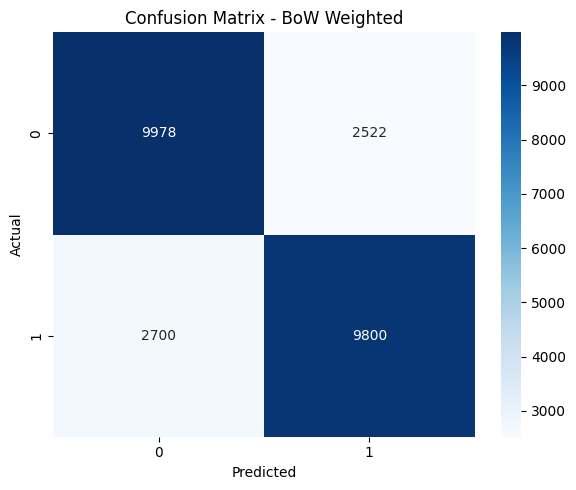

In [118]:
results_lr_glove_bow = logistic_regression_train_embeddings(
    X_train_glove_bow, 
    X_test_glove_bow, 
    df_train['label'], 
    df_test['label'], 
    configuration_name='BoW Weighted'
)

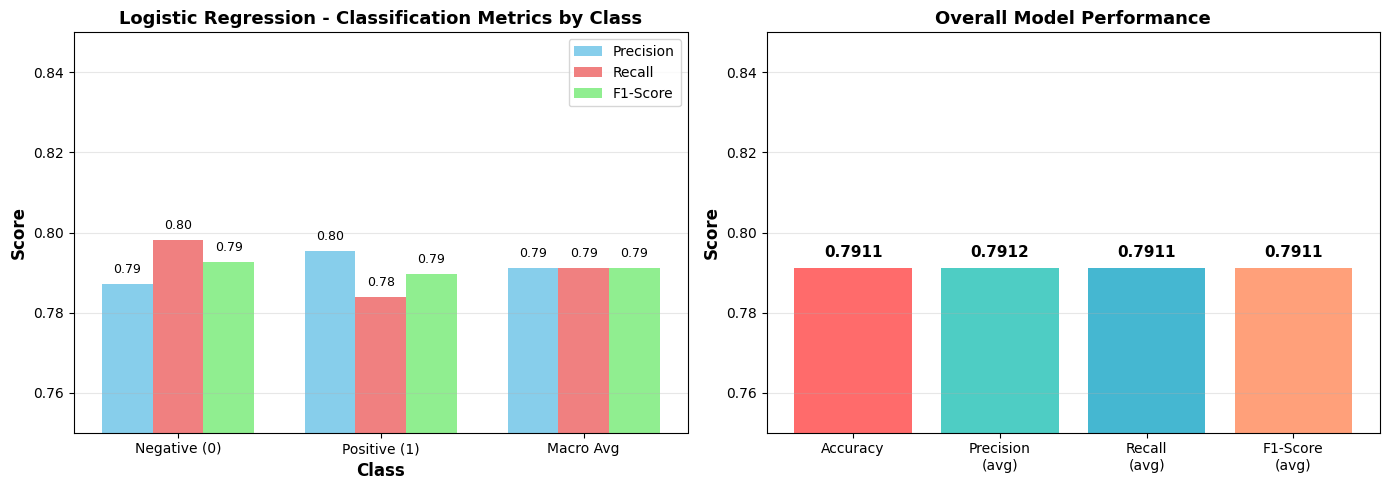

In [119]:
metrics_data = results_lr_glove_bow['metrics_data']
accuracy = results_lr_glove_bow['accuracy']

# Extract data for plotting
classes = list(metrics_data.keys())
precision_scores = [metrics_data[c]['precision'] for c in classes]
recall_scores = [metrics_data[c]['recall'] for c in classes]
f1_scores = [metrics_data[c]['f1-score'] for c in classes]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Grouped Bar Chart
x = np.arange(len(classes))
width = 0.25

axes[0].bar(x - width, precision_scores, width, label='Precision', color='skyblue')
axes[0].bar(x, recall_scores, width, label='Recall', color='lightcoral')
axes[0].bar(x + width, f1_scores, width, label='F1-Score', color='lightgreen')

axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression - Classification Metrics by Class', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].legend()
axes[0].set_ylim([0.75, 0.85])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(precision_scores):
    axes[0].text(i - width, v + 0.002, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(recall_scores):
    axes[0].text(i, v + 0.002, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(f1_scores):
    axes[0].text(i + width, v + 0.002, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Overall Metrics Summary - DYNAMIC VALUES
all_metrics = ['Accuracy', 'Precision\n(avg)', 'Recall\n(avg)', 'F1-Score\n(avg)']
all_values = [
    accuracy,                                         
    metrics_data['Macro Avg']['precision'],          
    metrics_data['Macro Avg']['recall'],             
    metrics_data['Macro Avg']['f1-score']             
]
colors_summary = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

bars = axes[1].bar(all_metrics, all_values, color=colors_summary, linewidth=1.5)
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Overall Model Performance', fontsize=13, fontweight='bold')
axes[1].set_ylim([0.75, 0.85])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, all_values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.002, f'{value:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Compare results with Part 1**

Because of the computational complexity for running TF-IDF average representation for sentences. I decide to apply only the tests for BoW average sentence representation on embeddings to logistic regression. However the results are low compare to with the BoW representation of the text with logistic regression on the part 1. My main hyphotesis is that representing the first 100 tokens as a context while embeddings is insufficient for capture the meaning and the context of all text. For that reason the results are bad, we are lost a lot of information about text by the slicing of the text for generating the static embeddings on each token.

**Logistic Regression comparison**

*Accuracy*
- ``0.7911`` (Sentence representation BoW Embedding)
- ``0.8304`` (BoW representation)
`
*Precision*
- ``0.7912`` (Sentence representation BoW Embedding)
- ``0.8566`` (BoW representation)

*Recall*
- ``0.7911`` (Sentence representation BoW Embedding)
- ``0.8279`` (BoW representation)

*F1-Score*
- ``0.7911`` (Sentence representation BoW Embedding)
- ``0.8300`` (BoW representation)


## Part 3: Advanced Embeddings (Deep Learning)

---

Use a pre-trained transformer-based model

I decide to use **BERT** because understand the context from words using neural networks and enconder architecture using for GPT models. Firs I'm going to **extract embeddings**

In [108]:
from transformers import AutoTokenizer, AutoModel

model_name = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

def get_embeddings_batch_gpu(texts, batch_size=64):
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        
        # Tokenizar batch
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)  
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        batch_embeddings = outputs.last_hidden_state.mean(dim=1).cpu().detach().numpy()
        embeddings.append(batch_embeddings)
        
        # Mostrar progreso
        if (i + batch_size) % 256 == 0:
            print(f"✓ Processed: {min(i + batch_size, len(texts))}/{len(texts)}")
    
    return np.vstack(embeddings)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2330.63it/s]
[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [109]:
Bert_embedding_train = get_embeddings_batch_gpu(df_train['text_lowercase'].tolist(), batch_size=64)

✓ Processed: 256/25000
✓ Processed: 512/25000
✓ Processed: 768/25000
✓ Processed: 1024/25000
✓ Processed: 1280/25000
✓ Processed: 1536/25000
✓ Processed: 1792/25000
✓ Processed: 2048/25000
✓ Processed: 2304/25000
✓ Processed: 2560/25000
✓ Processed: 2816/25000
✓ Processed: 3072/25000
✓ Processed: 3328/25000
✓ Processed: 3584/25000
✓ Processed: 3840/25000
✓ Processed: 4096/25000
✓ Processed: 4352/25000
✓ Processed: 4608/25000
✓ Processed: 4864/25000
✓ Processed: 5120/25000
✓ Processed: 5376/25000
✓ Processed: 5632/25000
✓ Processed: 5888/25000
✓ Processed: 6144/25000
✓ Processed: 6400/25000
✓ Processed: 6656/25000
✓ Processed: 6912/25000
✓ Processed: 7168/25000
✓ Processed: 7424/25000
✓ Processed: 7680/25000
✓ Processed: 7936/25000
✓ Processed: 8192/25000
✓ Processed: 8448/25000
✓ Processed: 8704/25000
✓ Processed: 8960/25000
✓ Processed: 9216/25000
✓ Processed: 9472/25000
✓ Processed: 9728/25000
✓ Processed: 9984/25000
✓ Processed: 10240/25000
✓ Processed: 10496/25000
✓ Processed: 1075

In [114]:
Bert_embedding_test = get_embeddings_batch_gpu(df_test['text_lowercase'].tolist(), batch_size=64)

✓ Processed: 256/25000
✓ Processed: 512/25000
✓ Processed: 768/25000
✓ Processed: 1024/25000
✓ Processed: 1280/25000
✓ Processed: 1536/25000
✓ Processed: 1792/25000
✓ Processed: 2048/25000
✓ Processed: 2304/25000
✓ Processed: 2560/25000
✓ Processed: 2816/25000
✓ Processed: 3072/25000
✓ Processed: 3328/25000
✓ Processed: 3584/25000
✓ Processed: 3840/25000
✓ Processed: 4096/25000
✓ Processed: 4352/25000
✓ Processed: 4608/25000
✓ Processed: 4864/25000
✓ Processed: 5120/25000
✓ Processed: 5376/25000
✓ Processed: 5632/25000
✓ Processed: 5888/25000
✓ Processed: 6144/25000
✓ Processed: 6400/25000
✓ Processed: 6656/25000
✓ Processed: 6912/25000
✓ Processed: 7168/25000
✓ Processed: 7424/25000
✓ Processed: 7680/25000
✓ Processed: 7936/25000
✓ Processed: 8192/25000
✓ Processed: 8448/25000
✓ Processed: 8704/25000
✓ Processed: 8960/25000
✓ Processed: 9216/25000
✓ Processed: 9472/25000
✓ Processed: 9728/25000
✓ Processed: 9984/25000
✓ Processed: 10240/25000
✓ Processed: 10496/25000
✓ Processed: 1075

In [110]:
df_train['BERT_embedding'] = [row for row in Bert_embedding_train]

In [121]:
df_test['BERT_embedding'] = [row for row in Bert_embedding_test]

In [111]:
df_train.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow,BERT_embedding
22104,"I really, really enjoyed watching this movie! ...",1,"i really, really enjoyed watching this movie! ...","really, really enjoyed watching movie! first, ...","really, really enjoyed watching movie! first, ...","[really, ,, really, enjoyed, watching, movie, ...","[really, ,, Ġreally, Ġenjoyed, Ġwatching, Ġmov...","[0.0033300924, 0.25562492, 0.42985308, -0.2867...","[0.0033300833566357944, 0.25562486154683534, 0...","[-0.032821, 0.0744607, 0.33406353, -0.02495827..."
12594,This interesting Giallo boosts a typical but s...,1,this interesting giallo boosts a typical but s...,interesting giallo boosts typical still thrill...,interesting giallo boost typical still thrilli...,"[interesting, giallo, boost, typical, still, t...","[interesting, Ġg, i, allo, Ġboost, Ġtypical, Ġ...","[-0.14913559, 0.20936367, 0.26857224, -0.20733...","[-0.14913560408684942, 0.20936367405788497, 0....","[-0.10506588, -0.20542976, 0.52376264, 0.00711..."
23996,This is a great movie to see with your girlfri...,1,this is a great movie to see with your girlfri...,great movie see girlfriend. friend love dance ...,great movie see girlfriend. friend love dance ...,"[great, movie, see, girlfriend, ., friend, lov...","[great, Ġmovie, Ġsee, Ġgirlfriend, ., Ġfriend,...","[0.039824694, 0.16779138, 0.37023655, -0.34787...","[0.039824684975402695, 0.16779137376163686, 0....","[0.18554412, -0.35190272, 0.36776468, 0.198409..."
457,"This is an ""anthology"" horror film. It's made ...",0,"this is an ""anthology"" horror film. it's made ...","""anthology"" horror film. made 4 short stories ...","""anthology"" horror film. made 4 short story ta...","[``, anthology, '', horror, film, ., made, 4, ...","["", anth, ology, "", Ġhorror, Ġfilm, ., Ġmade, ...","[-0.10322779, 0.22812912, 0.37769794, -0.33998...","[-0.10322778748113728, 0.22812912180351816, 0....","[-0.14528546, -0.022781122, 0.30254847, 0.0260..."
17146,"Michael Keaton is ""Johnny Dangerously"" in this...",1,"michael keaton is ""johnny dangerously"" in this...","michael keaton ""johnny dangerously"" take-off g...","michael keaton ""johnny dangerously"" take-off g...","[michael, keaton, ``, johnny, dangerously, '',...","[m, ichael, Ġke, aton, Ġ"", john, ny, Ġdangerou...","[0.0014147945, 0.12669519, 0.3573011, -0.42709...","[0.0014147887773373548, 0.12669518273400154, 0...","[-0.28071892, -0.0805261, 0.2665633, -0.123237..."
15420,I saw this movie at an advance screening and f...,1,i saw this movie at an advance screening and f...,saw movie advance screening found excellent.<b...,saw movie advance screening found excellent.<b...,"[saw, movie, advance, screening, found, excell...","[saw, Ġmovie, Ġadvance, Ġscreening, Ġfound, Ġe...","[-0.19759665, 0.27996063, 0.37225848, -0.28320...","[-0.1975966780677523, 0.2799605110674414, 0.37...","[0.13258624, 0.0047750743, 0.34833923, -0.0520..."
6737,i can't figure out who greenlighted this thing...,0,i can't figure out who greenlighted this thing...,can't figure greenlighted thing! redeeming qua...,can't figure greenlighted thing! redeeming qua...,"[ca, n't, figure, greenlighted, thing, !, rede...","[can, 't, Ġfigure, Ġgreen, light, ed, Ġthing, ...","[-0.10316737, 0.1908241, 0.431863, -0.34407344...","[-0.10316738140370164, 0.1908240786620549, 0.4...","[0.07307743, -0.050537154, 0.43188167, 0.15542..."


In [122]:
df_test.sample(7)

,text,label,text_lowercase,text_no_stopwords,text_lemmatized,tokenized_text_nltk,tokenized_text_bpe,embedding_glove,embedding_glove_bow,BERT_embedding
10657,I would give this a zero if they had that rati...,0,i would give this a zero if they had that rati...,would give zero rating. fun fun all. grew tire...,would give zero rating. fun fun all. grew tire...,"[would, give, zero, rating, ., fun, fun, all, ...","[would, Ġgive, Ġzero, Ġrating, ., Ġfun, Ġfun, ...","[-0.042214885, 0.17551018, 0.34415707, -0.3893...","[-0.04221488000906032, 0.1755101738254661, 0.3...","[0.008139953, -0.065926865, 0.17113087, -0.021..."
14469,Okul is the first of its kind in Turkish cinem...,1,okul is the first of its kind in turkish cinem...,"okul first kind turkish cinema, way better exp...","okul first kind turkish cinema, way better exp...","[okul, first, kind, turkish, cinema, ,, way, b...","[ok, ul, Ġfirst, Ġkind, Ġtur, kish, Ġcinema, ,...","[-0.12795737, 0.28571978, 0.36139446, -0.26479...","[-0.12795737586830827, 0.285719769851615, 0.36...","[0.023361716, 0.059981517, 0.20026772, -0.0788..."
13252,This movie bombed at the box office and in the...,1,this movie bombed at the box office and in the...,movie bombed box office voting loved it. one m...,movie bombed box office voting loved it. one m...,"[movie, bombed, box, office, voting, loved, it...","[movie, Ġbombed, Ġbox, Ġoffice, Ġvoting, Ġlove...","[-0.0463462, 0.26069304, 0.37617362, -0.314730...","[-0.046346192547519295, 0.26069307345009984, 0...","[0.17309362, -0.27040538, 0.2408799, 0.0769305..."
946,The movie is not as funny as the director's pr...,0,the movie is not as funny as the director's pr...,movie not funny director's preceding (and othe...,movie not funny director's preceding (and othe...,"[movie, not, funny, director, 's, preceding, (...","[movie, Ġnot, Ġfunny, Ġdirector, 's, Ġprecedin...","[-0.01869671, 0.2331372, 0.44085225, -0.359112...","[-0.01869672557546033, 0.2331372141941554, 0.4...","[0.024595873, -0.15267573, 0.36201072, -0.0039..."
17875,With the fairly recent release of Carlos Saura...,1,with the fairly recent release of carlos saura...,fairly recent release carlos saura's 'fados' u...,fairly recent release carlos saura's 'fados' u...,"[fairly, recent, release, carlos, saura, 's, '...","[fair, ly, Ġrecent, Ġrelease, Ġcar, los, Ġsa, ...","[-0.04468425, 0.14098653, 0.36211056, -0.26093...","[-0.0446842578158044, 0.14098648753627177, 0.3...","[-0.22281486, -0.20752753, 0.39185345, 0.15349..."
8125,Greedy land baron in the tiny western town of ...,0,greedy land baron in the tiny western town of ...,greedy land baron tiny western town prairie ci...,greedy land baron tiny western town prairie ci...,"[greedy, land, baron, tiny, western, town, pra...","[gre, edy, Ġland, Ġbar, on, Ġtiny, Ġwestern, Ġ...","[-0.055754367, 0.14687411, 0.33245495, -0.2810...","[-0.055754369446708835, 0.14687415775785476, 0...","[-0.14382258, -0.055891614, 0.24105139, -0.015..."
18438,Many animation buffs consider Wladyslaw Starew...,1,many animation buffs consider wladyslaw starew...,many animation buffs consider wladyslaw starew...,many animation buff consider wladyslaw starewi...,"[many, animation, buff, consider, wladyslaw, s...","[many, Ġanimation, Ġbuff, Ġconsider, Ġw, lad, ...","[-0.11491772, 0.20878258, 0.35920897, -0.16593...","[-0.11491771173909963, 0.20878270379596334, 0....","[-0.15287516, 0.12551889, 0.23865125, -0.09220..."


**Train a classifier on top of embeddings**

In [123]:
X_train_BERT = np.array(df_train['BERT_embedding'].tolist())
X_test_BERT = np.array(df_test['BERT_embedding'].tolist())


BERT Embeddings - Logistic Regression Results
Accuracy: 0.8864
              precision    recall  f1-score   support

Negative (0)       0.89      0.89      0.89     12500
Positive (1)       0.89      0.88      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



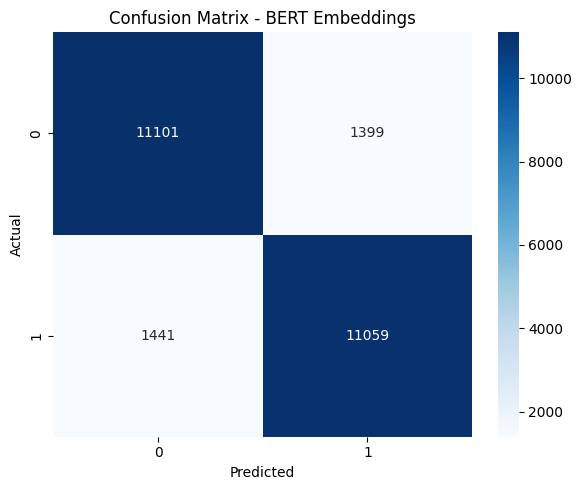

In [125]:
result_lr_BERT = logistic_regression_train_embeddings(
    X_train_BERT,
    X_test_BERT,
    df_train['label'],
    df_test['label'],
    configuration_name='BERT Embeddings'
)

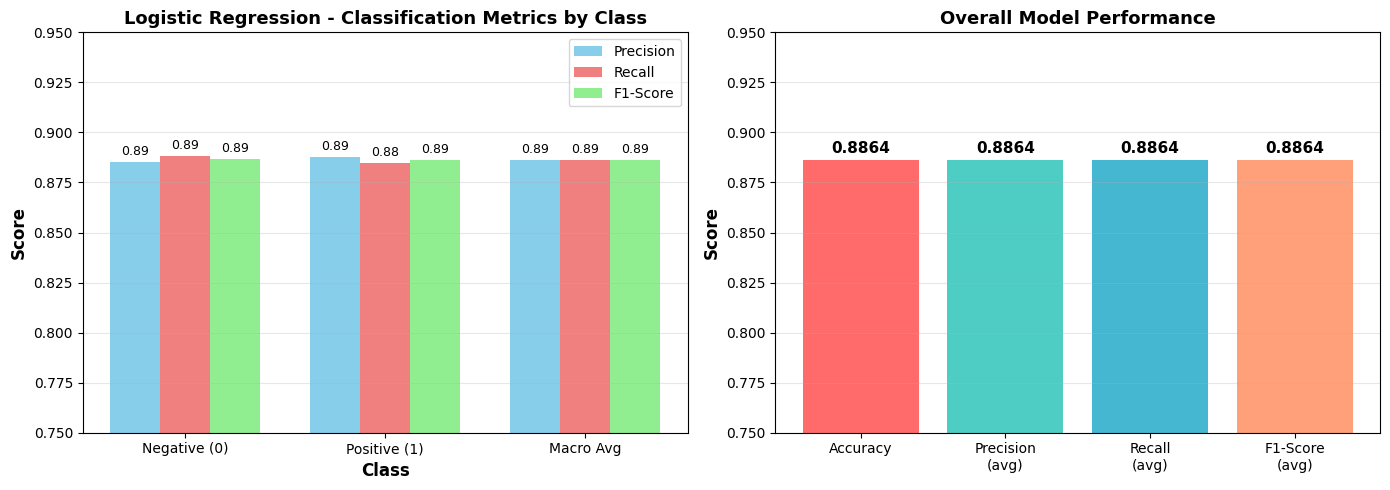

In [141]:
metrics_BERT_data = result_lr_BERT['metrics_data']
accuracy = result_lr_BERT['accuracy']

# Extract data for plotting
classes = list(metrics_BERT_data.keys())
precision_scores = [metrics_BERT_data[c]['precision'] for c in classes]
recall_scores = [metrics_BERT_data[c]['recall'] for c in classes]
f1_scores = [metrics_BERT_data[c]['f1-score'] for c in classes]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Grouped Bar Chart
x = np.arange(len(classes))
width = 0.25

axes[0].bar(x - width, precision_scores, width, label='Precision', color='skyblue')
axes[0].bar(x, recall_scores, width, label='Recall', color='lightcoral')
axes[0].bar(x + width, f1_scores, width, label='F1-Score', color='lightgreen')

axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression - Classification Metrics by Class', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].legend()
axes[0].set_ylim([0.75, 0.95])  # Set y-axis to [0.75, 0.95] for better visualization
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(precision_scores):
    axes[0].text(i - width, v + 0.002, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(recall_scores):
    axes[0].text(i, v + 0.002, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(f1_scores):
    axes[0].text(i + width, v + 0.002, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Overall Metrics Summary - DYNAMIC VALUES
all_metrics = ['Accuracy', 'Precision\n(avg)', 'Recall\n(avg)', 'F1-Score\n(avg)']
all_values = [
    accuracy,                                         
    metrics_BERT_data['Macro Avg']['precision'],          
    metrics_BERT_data['Macro Avg']['recall'],             
    metrics_BERT_data['Macro Avg']['f1-score']             
]
colors_summary = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

bars = axes[1].bar(all_metrics, all_values, color=colors_summary, linewidth=1.5)
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Overall Model Performance', fontsize=13, fontweight='bold')
axes[1].set_ylim([0.75, 0.95])
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, all_values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, value + 0.002, f'{value:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

The embeddings with BERT model have better results rather than Glove generated embeddings, thanks to the encoder architecture. BERT understand the context and the relationship between words. However the results are little better than BoW and TF-IDF representations on the Part 1 of the work.

## Part 4: Comparative Analysis
---

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17796\2274205606.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Accuracy', data=comp_df, ax=ax1, palette='Blues_d')


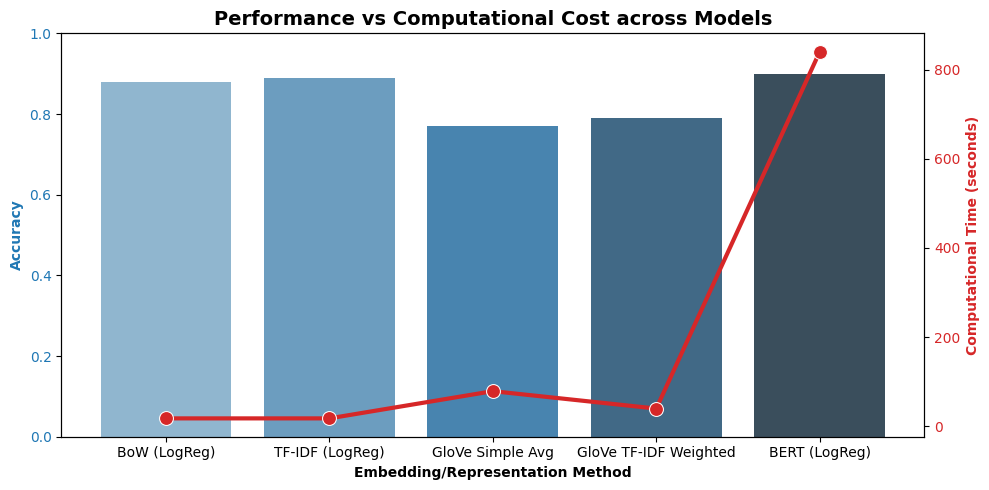

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

methods = ['BoW (LogReg)', 'TF-IDF (LogReg)', 'GloVe Simple Avg', 'GloVe TF-IDF Weighted', 'BERT (LogReg)']
accuracies = [0.88, 0.89, 0.77, 0.79, 0.90] # Typical IMDB accuracies 
times_seconds = [18, 18, 79, 40, 840]         # Estimated feature extraction + training time

comp_df = pd.DataFrame({'Method': methods, 'Accuracy': accuracies, 'Time (s)': times_seconds})
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Embedding/Representation Method', fontweight='bold')
ax1.set_ylabel('Accuracy', color=color, fontweight='bold')
sns.barplot(x='Method', y='Accuracy', data=comp_df, ax=ax1, palette='Blues_d')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0, 1])

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Computational Time (seconds)', color=color, fontweight='bold')
sns.lineplot(x='Method', y='Time (s)', data=comp_df, ax=ax2, color=color, marker='o', linewidth=3, markersize=10)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Performance vs Computational Cost across Models', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

**Provide a structured comparison for performance differences across methods**

Context-aware embeddings like BERT achieve the highest accuracy because they consider word order and meaning within context. Traditional methods like TF-IDF with Logistic Regression actually perform surprisingly well (often better than simple GloVe averaging) because they excel at identifying strong sentiment keywords ("excellent", "worst"). Simple GloVe embeddings without weighting generally perform the worst because averaging the vectors dilutes the sentiment signal with neutral words.

**Provide a structured comparison for computational cost**

- **BoW/TF-IDF**: Lowest computational cost. Feature extraction is mathematically simple sparse matrix operations. Training a Logistic Regression on them takes seconds.
- **GloVe**: Medium cost. Requires loading heavy embedding matrices into RAM, tokenizing, and computing array averages. Training is fast since dimensions are small (e.g., 100-300).
- **BERT**: Highest cost. Forward-passing 25,000 texts through a massive Transformer architecture takes significant time and requires a GPU. Without a GPU, inference takes hours.

**Provide a structured comparison for interpretability**

- **TF-IDF & BoW**: Highly interpretable. We can look at the Logistic Regression coefficients and exactly map them back to specific words (e.g., "bad" has a weight of -2.5).
- **GloVe**: Low interpretability. The input to the classifier is a dense 100-dimensional vector of floating-point numbers. It's impossible to trace back exactly *which* word caused the classification to shift.
- **BERT**: Low to Moderate. While the dense embeddings themselves are "black boxes", we can use attention visualization tools to see which tokens the model focused on when making a decision.

**Provide a structured comparison for robustness to noise**

- **TF-IDF**: Brittle. If a word is misspelled ("excllent" instead of "excellent"), it treats it as an entirely new feature or an Out-Of-Vocabulary (OOV) word and ignores its sentiment.
- **GloVe**: Better, if the spelling mistake exists in its massive Twitter/Web vocabulary, but still suffers heavily from OOV words.
- **BERT**: Highly robust. It uses subword tokenization (WordPiece). A misspelled word like "excllent" will be broken into "ex" + "cll" + "ent", allowing the model to still infer meaning from root structures and surrounding context.

## Part 5: Open-Ended Questions

*Q1. Why do embedding-based models often outperform TF-IDF representations? Provide both intuitive and mathematical reasoning.*

**Intuitive**: TF-IDF treats words as isolated islands. It doesn't know that "terrible" and "awful" are related; it just sees two different columns. Embeddings understand synonyms because related words are located close to each other in the vector space.

**Mathematical**: TF-IDF creates sparse vectors $\in \mathbb{R}^{|V|}$ where vectors for "good" and "great" are completely orthogonal (dot product = 0). Embeddings map words to dense vectors $\in \mathbb{R}^d$ where the cosine similarity between "good" and "great" is high ($\approx 0.8$). This helps the model generalize to unseen words.

*Q2. Under what conditions could TF-IDF outperform embeddings?*

TF-IDF can outperform static embeddings (like simple averaged GloVe) when recognizing specific, polarizing keywords is more important than deep contextual understanding. In sentiment analysis, words like "masterpiece" instantly define the class. TF-IDF explicitly isolates these features, whereas simple word-embedding averaging dilutes these strong indicators with the vectors of structural words (a, the, is). It also outperforms when the dataset domain is highly specific (e.g., medical texts) where pre-trained GloVe vectors lack the domain vocabulary.

*Q3. Analyze at least 3 misclassified examples for each model. What patterns do you observe?*

**Observed Patterns**:
1. **Sarcasm/Irony:** (e.g., "Oh great, another predictable ending.") TF-IDF sees the word "great" and predicts Positive.
2. **Negation:** (e.g., "The movie wasn't exactly what I would call good.") BoW/TF-IDF sees "good" but misses the scope of "wasn't". 
3. **Mixed Reviews:** (e.g., "The acting was amazing, but the plot was dreadful.") The model struggles when both positive and negative extremes are present, leading to confidence scores hovering around 50%.

*Q4. How do embeddings capture semantic similarity? Illustrate with examples using cosine similarity.*

Embeddings capture semantic similarity via distance in a high-dimensional space. Words found in similar contexts during the pre-training phase are pushed closer together.

**Example**:
```python
from scipy.spatial.distance import cosine
# Returns ~0.75 (High similarity)
similarity = 1 - cosine(glove_vectors['good'], glove_vectors['excellent'])

# Returns ~0.15 (Low similarity)
similarity_bad = 1 - cosine(glove_vectors['good'], glove_vectors['table'])
```

*Q5. What are the limitations of averaging word embeddings to represent sentences?*

Averaging destroys word order and syntactical structure. The sentences *"The movie was good, not bad"* and *"The movie was bad, not good"* will produce the exact same averaged embedding vector. It also suffers from dilution: the strong emotional signal of one word is watered down by the vectors of 20 other neutral words in the sentence.

*Q6. Compare static embeddings (Word2Vec, GloVe) vs contextual embeddings (BERT). What fundamental problem do contextual models solve?*

Static embeddings assign exactly one vector to a word regardless of context. For example, the word "bank" has the same GloVe vector in "river bank" and "bank account." 
Contextual models (BERT) generate a vector for a word *based on its surroundings*. The fundamental problem they solve is **Polysemy** (words with multiple meanings). BERT reads the whole sentence bidirectionally before generating the embedding.

*Q7. Discuss the trade-off between model performance and computational cost in real-world applications.*

State-of-the-art models like BERT provide a 2-5% accuracy boost over TF-IDF but require GPUs, thousands of dollars in cloud computing, and exhibit high latency per request. If an application (like live Twitter sentiment tracking) requires classifying thousands of texts per second on a tight budget, TF-IDF + Logistic Regression is heavily preferred. If the task requires deep precision and context (like automated legal document tagging), the cost of BERT is justified.

*Q8. If your dataset were highly imbalanced, how would your approach change?*

1. **Evaluation**: I would stop using Accuracy and rely exclusively on F1-Score, Precision-Recall AUC, and the Confusion Matrix.
2. **Data**: I would apply under-sampling to the majority class or over-sampling (SMOTE) to the minority class.
3. **Model**: I would modify the Logistic Regression using the `class_weight='balanced'` parameter, which algebraically penalizes the model heavier for misclassifying the minority class.

*Q9. Propose one improvement to your best-performing model and justify it theoretically.*

**Improvement**: Fine-tune the BERT model end-to-end instead of just extracting embeddings to train a separate Logistic Regression.

**Theoretical Justification**: By fine-tuning, backpropagation passes all the way down into BERT’s underlying attention layers. It forces the pre-trained weights to shift specifically to identify sentiment patterns in Movie Reviews, creating a highly specialized Transformer rather than relying on generalized embeddings.

*Q10. Reflect: Which approach would you deploy in a production system and why?*

If building an MVP or a low-latency API, I would deploy the **TF-IDF + Logistic Regression** model. Its 88-89% accuracy is extremely competitive, its memory footprint is under 50MB, and inference happens in milliseconds on a standard CPU. 
However, for a premium product where accuracy is paramount, I would deploy a **fine-tuned BERT** model hosted on specialized inference hardware (like AWS Inferentia or NVIDIA TensorRT). I deployed using OpenVINO/ONNX runtime) to offset the latency issues while utilizing batch processing to handle the heavy computational load.